In [2]:
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf
import pandas as pd
import numpy as np
import cvxpy as cp
import time
from matplotlib.ticker import ScalarFormatter
from datetime import datetime, timedelta
from scipy.optimize import minimize
from scipy.stats import wilcoxon

In [19]:
# Choose 10 assets for the portfolio and use ^TNX to calculate the risk-free rate.assets = ["NVDA", "TSLA", "AVGO", "TPL", "NFLX", "AXON", "FICO", "URI", "TDG", "DPZ", "^TNX"]
assets = ["NVDA", "TSLA", "AVGO", "TPL", "NFLX", "AXON", "FICO", "URI", "TDG", "DPZ", "^TNX"]
# Define fixed end date and start date (15 years back)
end_date = datetime(2025, 4, 30)
start_date = end_date - timedelta(adays=15 * 365)  # Approx. 15 years before

# Format dates as strings in YYYY-MM-DD format
start_str = start_date.strftime('%Y-%m-%d')
end_str = end_date.strftime('%Y-%m-%d')

print(f"The dataset covers the period from {start_str} to {end_str}.")

# Download adjusted close prices using yfinance
try:
    data = yf.download(assets, start=start_str, end=end_str, auto_adjust=False)['Adj Close']
except Exception as e:
    print(f"Error downloading data: {e}")
    exit(1)

# Convert 10-year Treasury yield (annualized) to decimal for risk-free rate
data["yearly_yield"] = data["^TNX"] / 100

# Resample data to yearly frequency and drop rows with missing values
yearly_data = data.resample('YE').last().dropna()  # 'YE' means year-end

# Compute average annual risk-free rate
mean_yield = yearly_data["yearly_yield"].mean()

# Calculate annual percentage returns for each asset (excluding ^TNX and yield column)
returns = yearly_data.drop(columns=["^TNX", "yearly_yield"]).pct_change().dropna()

# Define lower and upper bounds for asset weights (between 5% and 50% for each)
lower_bounds = np.array([0.05] * len(returns.columns))
upper_bounds = np.array([0.5] * len(returns.columns))

# Compute mean returns and covariance matrix
mean_returns = returns.mean()
cov_matrix = returns.cov()

# Convert returns DataFrame to NumPy array for optimizer compatibility
returns_matrix = returns.to_numpy()

# Handle any NaN values in the returns matrix
if np.any(np.isnan(returns_matrix)):
    print("Warning: Returns matrix contains NaN values. Filling with zeros.")
    returns_matrix = np.nan_to_num(returns_matrix)

# Ensure that the sum of upper bounds is sufficient to allow feasible portfolios
if np.sum(upper_bounds) < 1:
    print("Error: The sum of upper bounds is less than 1.")
    exit(1)

# Validate that all lower bounds are less than corresponding upper bounds
if np.any(lower_bounds > upper_bounds):
    print("Error: Some lower bounds are greater than the corresponding upper bounds.")
    exit(1)

# Print for debugging and verification
print(f"Mean Returns: {mean_returns}")
print(f"Covariance Matrix: \n{cov_matrix}")
print(f"Returns Matrix: \n{returns_matrix}")
print("Data successfully loaded and prepared for further optimization.")


[                       0%                       ]

The dataset covers the period from 2010-05-04 to 2025-04-30.


[*********************100%***********************]  11 of 11 completed


Mean Returns: Ticker
AVGO    0.409619
AXON    0.443290
DPZ     0.313681
FICO    0.378375
NFLX    0.482280
NVDA    0.700738
TDG     0.302821
TPL     0.447898
TSLA    0.905191
URI     0.302921
dtype: float64
Covariance Matrix: 
Ticker      AVGO      AXON       DPZ      FICO      NFLX      NVDA       TDG  \
Ticker                                                                         
AVGO    0.166207  0.085854 -0.001589  0.045962  0.147093  0.240268  0.029082   
AXON    0.085854  0.169417 -0.000440  0.048073  0.083754  0.104767  0.044485   
DPZ    -0.001589 -0.000440  0.103057 -0.008861  0.017465 -0.006040  0.010434   
FICO    0.045962  0.048073 -0.008861  0.102935  0.041685  0.103349  0.053867   
NFLX    0.147093  0.083754  0.017465  0.041685  0.719770  0.118696  0.019704   
NVDA    0.240268  0.104767 -0.006040  0.103349  0.118696  0.843463  0.036813   
TDG     0.029082  0.044485  0.010434  0.053867  0.019704  0.036813  0.056102   
TPL    -0.000425  0.043346 -0.027131 -0.014291  0.0351

In [34]:
class Heuristic:
  def __init__(self, mean_returns, cov_matrix, mean_yield, num_assets, asset_names=returns.columns,
                population_size=500, generations=2000, mutation_rate=0.3,
                elite_frac=0.1, min_weight=0.001, max_volatility=0.25, patience=100,
                returns=None):

      # === Input Parameters ===
      self.mean_returns = mean_returns              # Expected annual returns for each asset
      self.cov_matrix = cov_matrix                  # Covariance matrix of asset returns
      self.mean_yield = mean_yield                  # Average annual risk-free rate (e.g., 10Y Treasury yield)
      self.num_assets = num_assets                  # Number of assets in the portfolio
      self.asset_names = asset_names                # Names of the assets

      # === Genetic Algorithm Hyperparameters ===
      self.population_size = max(50, population_size)  # Number of candidate portfolios per generation
      self.generations = generations                   # Maximum number of generations to evolve
      self.base_mutation_rate = mutation_rate          # Base probability of mutating an individual
      self.elite_size = max(1, int(elite_frac * population_size))  # Number of top performers to retain each generation
      self.min_weight = min_weight                     # Minimum allowable asset weight (e.g., 0.001)
      self.max_volatility = max_volatility             # Maximum allowable portfolio volatility
      self.patience = patience                         # Early stopping: number of generations without improvement before stopping

      # === Data and Risk-Free Rate ===
      self.returns = returns            # Historical asset returns (used to compute portfolio risk measures)
      self.risk_free_rate = mean_yield  # Alias for mean_yield, used in Sharpe ratio calculation

      # === Tracking Metrics (for diagnostics and plotting) ===
      self.best_sharpe_history = []     # Track best Sharpe ratio achieved over generations
      self.runtime_history = []         # Track time taken for each generation
      self.start_time = None            # To store start time for timing execution
      self.no_improvement_count = 0     # Counter for early stopping if no improvement is seen

      # === Risk Limits Calculation ===
      # Determine acceptable portfolio risk levels: Value-at-Risk (VaR) and Conditional VaR (CVaR)
      self.VaR_limit, self.CVaR_limit = self.compute_var_cvar_limit(n_iter=5000)


  # === General Function ===
  def sharpe_ratio(self, weights, mean_returns, cov_matrix, risk_free_rate):
    """
    Calculates the Sharpe Ratio for a given portfolio.

    Parameters:
    - weights: array-like, portfolio weights for each asset
    - mean_returns: array-like, expected returns of the assets
    - cov_matrix: 2D array, covariance matrix of asset returns
    - risk_free_rate: float, annualized risk-free rate (e.g., 10Y Treasury yield)

    Returns:
    - Sharpe Ratio: float, measure of risk-adjusted return
    """
    weights = np.array(weights)

    # Portfolio Expected Return
    portfolio_return = np.dot(weights, mean_returns)

    # Portfolio Volatility (Standard Deviation)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    # Sharpe Ratio Calculation
    # If volatility is zero (rare edge case), return negative infinity to penalize the solution
    if portfolio_volatility == 0:
        return -np.inf

    # Compute risk-adjusted return
    return (portfolio_return - risk_free_rate) / portfolio_volatility

  def compute_var_cvar(self, portfolio_returns, confidence_level=0.90):
    """
    Computes the Value at Risk (VaR) and Conditional Value at Risk (CVaR)
    for a given set of portfolio returns at a specified confidence level.

    Parameters:
    - portfolio_returns: NumPy array of historical portfolio returns.
    - confidence_level: float, the confidence level (e.g., 0.90 for 90%).

    Returns:
    - var: Value at Risk (threshold loss at the given confidence level)
    - cvar: Conditional Value at Risk (expected loss beyond the VaR threshold)
    """
    # Input Validation
    if not isinstance(portfolio_returns, np.ndarray):
        raise TypeError("portfolio_returns must be a NumPy array.")
    if len(portfolio_returns) == 0:
        raise ValueError("portfolio_returns is empty.")
    if not (0 < confidence_level < 1):
        raise ValueError("confidence_level must be between 0 and 1.")

    # Sort the returns in ascending order (worst losses first)
    sorted_returns = np.sort(portfolio_returns)

    # Calculate index corresponding to the (1 - confidence_level) percentile
    index = int((1 - confidence_level) * len(sorted_returns))

    # Protect against too small index (e.g., index=0) to ensure cvar won't get error
    if index < 1:
        raise ValueError(f"Confidence level too high for sample size. Try a lower confidence level (e.g. 0.90). Got index={index}.")

    # Compute VaR
    # VaR is the return value at the specified quantile (e.g., 10th percentile if confidence=0.90)
    var = sorted_returns[index]

    # Compute CVaR
    # CVaR is the average of returns worse than or equal to the VaR (left tail average)
    cvar = sorted_returns[:index].mean()

    return var, cvar

  def find_feasible_start_simplex_bounded(self, lower_bounds, upper_bounds):
    """
    Generates a feasible initial portfolio weight vector that:
    - Lies on the probability simplex (weights sum to 1)
    - Respects given lower and upper bounds for each asset

    This is done by:
    1. Sampling a random point from the Dirichlet distribution (uniform on simplex)
    2. Projecting it into the bounded feasible region using convex optimization

    Parameters:
        lower_bounds (np.ndarray): Lower bound for each asset's weight
        upper_bounds (np.ndarray): Upper bound for each asset's weight

    Returns:
        np.ndarray: A feasible weight vector that satisfies all constraints
    """
    n_assets = len(lower_bounds)

    # Step 1: Sample random point from Dirichlet (on simplex)
    w_random = np.random.dirichlet(np.ones(n_assets))

    # Step 2: Project to feasible region using convex optimization
    w = cp.Variable(n_assets)
    objective = cp.Minimize(cp.sum_squares(w - w_random))  # Keep randomness

    # Constraints: sum to 1 (simplex), respect bounds
    constraints = [
        cp.sum(w) == 1,
        w >= lower_bounds,
        w <= upper_bounds
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve()

    if w.value is None:
        raise ValueError("Could not find a feasible initial weight.")

    return w.value

  def compute_var_cvar_limit(self, n_iter=5000):
      """
      Computes the VaR and CVaR limits by simulating multiple random portfolios,
      evaluating their risk, and selecting conservative thresholds from the safest set.

      Parameters:
      - n_iter: int, number of random portfolios to simulate (must be > 0)

      Returns:
      - VaR_limit: float, minimum Value at Risk from the top safe portfolios
      - CVaR_limit: float, minimum Conditional Value at Risk from the top safe portfolios
      """

      # Validate inputs and attributes
      if not hasattr(self, 'mean_returns') or not hasattr(self, 'cov_matrix'):
          raise AttributeError("Object must have 'mean_returns' and 'cov_matrix' attributes.")
      if not isinstance(n_iter, int) or n_iter <= 0:
          raise ValueError("n_iter must be a positive integer.")

      all_portfolios = []  # List to store simulation results

      for _ in range(n_iter):
          # Step 1: Generate an initial feasible solution that lies within the simplex and bounds
          bounded_weights = self.find_feasible_start_simplex_bounded(lower_bounds, upper_bounds)

          # Step 2: Apply Hit-and-Run sampling to perturb the solution while respecting bounds
          bounded_weights = self.hit_and_run_sampling(bounded_weights, lower_bounds, upper_bounds)

          # Step 3: Validate dimensions before matrix multiplication
          if returns_matrix.shape[1] != len(bounded_weights):
              raise ValueError("Dimension mismatch between returns_matrix and portfolio weights.")

          # Step 4: Compute portfolio return time series
          portfolio_returns = returns_matrix @ bounded_weights

          # Step 5: Compute Value-at-Risk (VaR) and Conditional Value-at-Risk (CVaR)
          var, cvar = self.compute_var_cvar(portfolio_returns)

          # Step 6: Calculate expected return and risk (standard deviation)
          portfolio_return = np.dot(self.mean_returns, bounded_weights)
          portfolio_risk = np.sqrt(np.dot(bounded_weights.T, np.dot(self.cov_matrix, bounded_weights)))

          # Step 7: Store the computed metrics for each portfolio
          all_portfolios.append({
              "weights": bounded_weights,
              "expected_return": portfolio_return,
              "risk": portfolio_risk,
              "VaR": var,
              "CVaR": cvar
          })

      # Ensure that at least one portfolio was successfully generated
      if len(all_portfolios) == 0:
          raise RuntimeError("No valid portfolios were generated.")

      # Create a risk measure combining VaR and CVaR for selection
      portfolio_df = pd.DataFrame(all_portfolios)
      portfolio_df["VaR_CVaR_sum"] = portfolio_df["VaR"] + portfolio_df["CVaR"]

      # Step 8: Select the top safest portfolios based on smallest combined risk (VaR + CVaR)
      top_fraction = 0.1  # Top 10% of portfolios
      top_n = max(1, int(top_fraction * len(portfolio_df)))   # Ensure at least one is selected
      top_safe_portfolios = portfolio_df.nlargest(top_n, "VaR_CVaR_sum")

      # Step 9: Determine conservative risk thresholds based on the safest portfolios
      VaR_limit = top_safe_portfolios["VaR"].min()  # Set the min VaR from top portfolios
      CVaR_limit = top_safe_portfolios["CVaR"].min()  # Set the min CVaR from top portfolios

      return VaR_limit, CVaR_limit

  def perform_wilcoxon_test(results_dict):
    """
    Performs pairwise Wilcoxon signed-rank tests on the results of different algorithms
    and prints the results in a table.

    Args:
        results_dict (dict): A dictionary where keys are algorithm names (str)
                            and values are lists of results (e.g., Sharpe ratios)
                            from each trial. Lists should have the same length,
                            using np.nan for failed trials.
    """
    print("\n=== Wilcoxon Signed-Rank Test Results (Pairwise Comparison) ===")

    algorithm_names = list(results_dict.keys())
    num_algorithms = len(algorithm_names)

    if num_algorithms < 2:
        print("Need at least two algorithms with valid data to perform pairwise comparisons.")
        return

    # Initialize a list to store comparison results
    comparison_results = []

    # Perform pairwise comparisons
    for i in range(num_algorithms):
        for j in range(i + 1, num_algorithms):
            alg1_name = algorithm_names[i]
            alg2_name = algorithm_names[j]
            results1 = results_dict.get(alg1_name, []) # Use .get with default empty list for safety
            results2 = results_dict.get(alg2_name, [])

            # Ensure lists have the same length for paired test by padding with NaN
            max_len = max(len(results1), len(results2))
            padded_results1 = results1 + [np.nan] * (max_len - len(results1))
            padded_results2 = results2 + [np.nan] * (max_len - len(results2))


            # Create paired data, excluding pairs with NaN in either result
            paired_data = [(r1, r2) for r1, r2 in zip(padded_results1, padded_results2) if not np.isnan(r1) and not np.isnan(r2)]

            if len(paired_data) < 2: # Wilcoxon test requires at least 2 data points
                print(f"Skipping comparison between {alg1_name} and {alg2_name}: Not enough paired valid data points ({len(paired_data)}).")
                # Store placeholder result for the table
                comparison_results.append({
                    "Algorithm 1": alg1_name,
                    "Algorithm 2": alg2_name,
                    "N (Valid Pairs)": len(paired_data),
                    "Wilcoxon Stat (W)": np.nan,
                    "P-value": np.nan,
                    "Significance (alpha=0.05)": "Skipped (Insufficient Data)"
                })
                continue

            # Separate the paired valid data back into two lists for wilcoxon test
            results1_valid = [pair[0] for pair in paired_data]
            results2_valid = [pair[1] for pair in paired_data]


            try:
                # Perform the Wilcoxon signed-rank test with a specified zero_method
                # 'wilcox': Assigns ranks only to non-zero differences.
                # 'pratt': Assigns ranks to all differences, including zeros.
                # 'zsplit': Used for larger sample sizes.
                # 'wilcox' is a common choice for smaller sample sizes like 12.
                statistic, p_value = wilcoxon(results1_valid, results2_valid, alternative='two-sided', zero_method='wilcox') # Added zero_method


                # Determine significance
                alpha = 0.05
                significance = "Reject H0 (Significant Difference)" if p_value < alpha else "Fail to Reject H0 (No Significant Difference)"

                # Store the results for this comparison
                comparison_results.append({
                    "Algorithm 1": alg1_name,
                    "Algorithm 2": alg2_name,
                    "N (Valid Pairs)": len(paired_data),
                    "Wilcoxon Stat (W)": statistic,
                    "P-value": p_value,
                    "Significance (alpha=0.05)": significance
                })



            except ValueError as ve:
                print(f"Could not perform Wilcoxon test for {alg1_name} vs {alg2_name} due to data issues: {ve}")
                comparison_results.append({
                    "Algorithm 1": alg1_name,
                    "Algorithm 2": alg2_name,
                    "N (Valid Pairs)": len(paired_data),
                    "Wilcoxon Stat (W)": np.nan,
                    "P-value": np.nan,
                    "Significance (alpha=0.05)": f"Error: {ve}"
                })
            except Exception as e:
                print(f"An unexpected error occurred during Wilcoxon test for {alg1_name} vs {alg2_name}: {e}")
                comparison_results.append({
                    "Algorithm 1": alg1_name,
                    "Algorithm 2": alg2_name,
                    "N (Valid Pairs)": len(paired_data),
                    "Wilcoxon Stat (W)": np.nan,
                    "P-value": np.nan,
                    "Significance (alpha=0.05)": f"Error: {e}"
                })


    # Print the results in a table format
    if comparison_results:
        df_comparisons = pd.DataFrame(comparison_results)
        # Format numerical columns for cleaner display, handle NaN formatting
        df_comparisons['Wilcoxon Stat (W)'] = df_comparisons['Wilcoxon Stat (W)'].apply(lambda x: f'{x:.4f}' if pd.notna(x) else 'NaN')
        df_comparisons['P-value'] = df_comparisons['P-value'].apply(lambda x: f'{x:.4f}' if pd.notna(x) else 'NaN')
        print("\nWilcoxon Signed-Rank Test Pairwise Comparison Results:")
        # Use to_string to avoid truncation of rows/columns in some environments
        print(df_comparisons.to_string(index=False))
    else:
        print("\nNo valid algorithm pairs found with sufficient data to perform Wilcoxon tests.")

  # === Function For Bayesian Optimization ===
  def prior(self, weights, alpha):
    """
    Computes the (unnormalized) Dirichlet prior probability for a given portfolio weight vector.

    Parameters:
        weights (np.ndarray): Portfolio weights, must lie on the simplex (i.e., non-negative and sum to 1).
        alpha (float): Concentration parameter of the Dirichlet distribution.
                       Higher alpha favors more uniform distributions; lower alpha favors sparse ones.

    Returns:
        float: Unnormalized prior probability (since the normalization constant B(α) is omitted).

    Notes:
        - The Dirichlet prior enforces that the weights lie on the simplex.
        - This function omits the normalization constant (Beta function) since it's constant across comparisons,
          making it cancel out in Metropolis-Hastings acceptance ratio.
    """

    # Validate input: weights must be a numpy array
    if not isinstance(weights, np.ndarray):
        raise TypeError("weights must be a NumPy array.")

    # Check that weights are non-negative (simplex constraint)
    if not np.all(weights >= 0):
        raise ValueError("weights must be non-negative.")

    # Check that weights sum to 1 (simplex constraint)
    if not np.isclose(np.sum(weights), 1):
        raise ValueError("weights must sum to 1.")

    # Alpha must be positive (valid Dirichlet parameter)
    if alpha <= 0:
        raise ValueError("alpha must be a positive value.")

    # Compute the unnormalized Dirichlet prior (ignoring Beta function B(α))
    return np.prod(weights**(alpha - 1))

  def hit_and_run_sampling(self, start, lower_bounds, upper_bounds, n_steps=1):
    """
    Generate a new sample using Hit-and-Run sampling within bounded simplex.

    Args:
        start (np.ndarray): Current feasible point (weights that sum to 1 and within bounds)
        lower_bounds (np.ndarray): Lower bounds for each weight
        upper_bounds (np.ndarray): Upper bounds for each weight
        n_steps (int): Number of sampling steps to take (more steps = more mixing)

    Returns:
        np.ndarray: New sample that satisfies the constraints
    """

    # Input checks
    if not isinstance(start, np.ndarray) or not isinstance(lower_bounds, np.ndarray) or not isinstance(upper_bounds, np.ndarray):
        raise TypeError("start, lower_bounds, and upper_bounds must be NumPy arrays.")
    if start.shape != lower_bounds.shape or start.shape != upper_bounds.shape:
        raise ValueError("start, lower_bounds, and upper_bounds must have the same shape.")
    if not np.isclose(np.sum(start), 1):
        raise ValueError("start weights must sum to 1.")
    if n_steps <= 0 or not isinstance(n_steps, int):
        raise ValueError("n_steps must be a positive integer.")

    x = start.copy()
    d = len(x)

    for _ in range(n_steps):
        # Step 1: Sample a random direction from a uniform distribution on the unit sphere
        direction = np.random.randn(d)
        direction -= np.mean(direction)  # Ensure sum(direction) = 0 to preserve sum(x) = 1
        direction /= np.linalg.norm(direction)  # Normalize

        # Step 2: Find maximum step size along direction within bounds
        t_min, t_max = -np.inf, np.inf

        for i in range(d):
            if direction[i] > 0:
                t_max = min(t_max, (upper_bounds[i] - x[i]) / direction[i])
                t_min = max(t_min, (lower_bounds[i] - x[i]) / direction[i])
            elif direction[i] < 0:
                t_max = min(t_max, (lower_bounds[i] - x[i]) / direction[i])
                t_min = max(t_min, (upper_bounds[i] - x[i]) / direction[i])

        if t_max < t_min:
            continue  # Invalid step, skip

        # Step 3: Sample a step size uniformly from the allowed range
        t = np.random.uniform(t_min, t_max)

        # Step 4: Move to the new point
        x = x + t * direction

    return x

  # === Main Code of Bayesian Optimization ===
  def bayesian_optimization(self, mean_returns, cov_matrix, risk_free_rate, n_iter, proposal_std=0.05, alpha = 1):
      """
      Performs Bayesian Optimization for portfolio selection using Metropolis-Hastings sampling.
      The objective is to maximize the Sharpe ratio while satisfying VaR and CVaR constraints.

      Parameters:
          mean_returns (np.ndarray): Expected returns of assets (1D array).
          cov_matrix (np.ndarray): Covariance matrix of asset returns (square matrix).
          risk_free_rate (float): Risk-free rate used in Sharpe ratio calculation.
          n_iter (int): Number of iterations for the sampling process.
          proposal_std (float): Standard deviation used in proposal distribution (for tuning).
          alpha (float): Concentration parameter for the Dirichlet prior.

      Returns:
          accepted_weights (np.ndarray): Accepted weight samples after burn-in.
          accepted_sharpes (np.ndarray): Corresponding Sharpe ratios.
          mean_sharpe (float): Mean Sharpe ratio after burn-in.
          std_sharpe (float): Standard deviation of Sharpe ratios.
          best_sharpe (float): Best Sharpe ratio found.
          best_weights (np.ndarray): Portfolio weights corresponding to best Sharpe ratio.
          top_weights (np.ndarray): Top 0.1% weight vectors by Sharpe ratio.
          top_sharpes (np.ndarray): Their corresponding Sharpe ratios.
          VaR_limit (float): VaR constraint used.
          CVaR_limit (float): CVaR constraint used.
      """

      # Input validation
      if mean_returns.ndim != 1:
          raise ValueError("mean_returns must be a 1D array.")
      if cov_matrix.shape[0] != cov_matrix.shape[1] or cov_matrix.shape[0] != mean_returns.shape[0]:
          raise ValueError("cov_matrix must be a square matrix and match mean_returns length.")
      if n_iter <= 0 or not isinstance(n_iter, int):
          raise ValueError("n_iter must be a positive integer.")
      if alpha <= 0:
          raise ValueError("alpha must be positive.")

      # Report limits for reference
      print(f"\nThe limit of VaR we selected here is: {self.VaR_limit:.5f}")
      print(f"The limit of CVaR we selected here is: {self.CVaR_limit:.5f}")

      # Step 1: Generate initial feasible solution
      bounded_weights = self.find_feasible_start_simplex_bounded(lower_bounds, upper_bounds)
      attempt_limit = 1000000  # To avoid infinite loops
      attempt = 0

      # Search for an initial portfolio satisfying VaR and CVaR constraints
      while attempt < attempt_limit:
          bounded_weights = self.hit_and_run_sampling(bounded_weights, lower_bounds, upper_bounds)
          portfolio_returns = returns_matrix @ bounded_weights
          var, cvar = self.compute_var_cvar(portfolio_returns)
          if var >= self.VaR_limit and cvar >= self.CVaR_limit:
              current_weights = bounded_weights
              current_sharpe = self.sharpe_ratio(current_weights, mean_returns, cov_matrix, risk_free_rate)
              break
          attempt += 1
      else:
          raise RuntimeError("Failed to generate initial portfolio satisfying VaR and CVaR constraints.")

      # Step 2: Metropolis-Hastings Sampling
      accepted_weights = [current_weights]
      accepted_sharpes = [current_sharpe]

      for _ in range(n_iter):
        attempt = 0
        while attempt < attempt_limit:
            # Propose new portfolio using constrained sampling
            proposal_weights = self.hit_and_run_sampling(current_weights, lower_bounds, upper_bounds)

            # Check VaR/CVaR constraints
            portfolio_returns = returns_matrix @ proposal_weights
            var, cvar = self.compute_var_cvar(portfolio_returns)

            if var < self.VaR_limit or cvar < self.CVaR_limit:
                attempt += 1
                continue

            # Calculate the Sharpe ratio for the proposed weights
            proposal_sharpe = self.sharpe_ratio(proposal_weights, mean_returns, cov_matrix, risk_free_rate)

            # Calculate the prior probability for the proposed weights
            proposal_prior = self.prior(proposal_weights, alpha)
            current_prior = self.prior(current_weights, alpha)

            # Log acceptance ratio to avoid numerical underflow
            log_acceptance_ratio = (
                proposal_sharpe - current_sharpe +
                np.log(proposal_prior + 1e-10) - np.log(current_prior + 1e-10)
            )
            acceptance_prob = min(1, np.exp(log_acceptance_ratio))

            # Accept or reject based on the acceptance probability
            if np.random.rand() < acceptance_prob:
                current_weights = proposal_weights
                current_sharpe = proposal_sharpe
                accepted_weights.append(current_weights)
                accepted_sharpes.append(current_sharpe)
            break
        else:
            print("Warning: Could not find valid proposal satisfying constraints.")

      # Step 3: Check validity of sampling result
      if len(accepted_sharpes) < int(n_iter * 0.2):
        raise RuntimeError("Too few valid samples passed constraints; consider relaxing VaR/CVaR or increasing attempts.")

      # Step 4: Post-sampling analysis
      best_index = np.argmax(accepted_sharpes)
      best_weights = accepted_weights[best_index]
      best_sharpe = accepted_sharpes[best_index]

      # Apply burn-in
      burn_in = int(n_iter * 0.2)
      accepted_weights = np.array(accepted_weights)[burn_in:]
      accepted_sharpes = np.array(accepted_sharpes)[burn_in:]

      # Statistics on posterior samples
      mean_sharpe = np.mean(accepted_sharpes)
      std_sharpe = np.std(accepted_sharpes)

      # Select top 0.1% portfolios by Sharpe
      threshold = np.percentile(accepted_sharpes, 99.9)
      top_indices = np.where(accepted_sharpes >= threshold)[0]
      top_weights = accepted_weights[top_indices]
      top_sharpes = accepted_sharpes[top_indices]

      return np.array(accepted_weights), np.array(accepted_sharpes), mean_sharpe, std_sharpe, best_sharpe, best_weights, top_weights, top_sharpes, self.VaR_limit, self.CVaR_limit

  # === Function for Genetic Optimization ===
  def initialize_population(self):
    """
    Initialize the population with random portfolio weights within bounds.

    Returns:
        np.ndarray: Initial population of portfolio weights.
    """
    population = []
    max_attempts = 1000000  # Prevent infinite loops

    for _ in range(self.population_size):

        # Apply bounded constraints
        bounded_weights = self.find_feasible_start_simplex_bounded(lower_bounds, upper_bounds)
        attempt = 0
        while attempt < max_attempts:
            try:
                bounded_weights = self.hit_and_run_sampling(bounded_weights, lower_bounds, upper_bounds)
                # Apply VaR and CVaR constraints
                portfolio_returns = returns_matrix @ bounded_weights
                var, cvar = self.compute_var_cvar(portfolio_returns)

                if var >= self.VaR_limit and cvar >= self.CVaR_limit:
                    population.append(bounded_weights)
                    break

            except Exception as e:
                print(f"Error during population initialization: {e}")

            attempt += 1
        else:
            raise RuntimeError("Could not initialize a valid individual after many attempts. Try loosening constraints.")

    return np.array(population)

  def tournament_selection(self, population, fitness, tournament_size=3):
      """
      Perform tournament selection to choose parents for the next generation.

      Args:
          population (np.ndarray): Current population of portfolio weights.
          fitness (np.ndarray): Fitness scores for each individual in the population.
          tournament_size (int): Number of individuals to compete in each tournament.

      Returns:
          np.ndarray: Selected parents for the next generation.
      """
      if len(population) != len(fitness):
        raise ValueError("Population size and fitness array size must match.")

      if tournament_size > len(population):
        raise ValueError("Tournament size cannot exceed population size.")

      selected = []
      for _ in range(self.population_size):
        try:
            contenders = np.random.choice(len(population), size=tournament_size, replace=False)
            best_index = np.argmax(fitness[contenders])
            winner = population[contenders[best_index]]
            selected.append(winner)

        except Exception as e:
            print(f"Error during tournament selection: {e}")
            continue

      return np.array(selected)

  def crossover(self, parent1, parent2):
      """
      Perform BLX-alpha crossover to generate a child portfolio.

      Args:
          parent1 (np.ndarray): Weights of the first parent.
          parent2 (np.ndarray): Weights of the second parent.

      Returns:
          np.ndarray: Weights of the child portfolio.
      """
      try:
        alpha = 0.5
        diff = np.abs(parent1 - parent2)
        min_vals = np.maximum(lower_bounds, parent1 - alpha * diff)
        max_vals = np.minimum(upper_bounds, parent2 + alpha * diff)
        child = np.random.uniform(min_vals, max_vals)

        if np.any(np.isnan(child)) or np.any(np.isinf(child)):
            raise ValueError("Generated child has invalid weights.")

        return child / child.sum()  # Normalize weights to sum to 1

      except Exception as e:
          print(f"Error during crossover: {e}. Returning average of parents.")
          fallback = (parent1 + parent2) / 2
          return fallback / fallback.sum()

  def mutate(self, individual):
    """
    Mutate a portfolio by perturbing weights and projecting back to the feasible simplex.

    Args:
        individual (np.ndarray): Original portfolio weights.
        lower_bounds (np.ndarray): Lower bounds for each weight.
        upper_bounds (np.ndarray): Upper bounds for each weight.

    Returns:
        np.ndarray: Mutated and feasible portfolio weights.
    """
    if np.random.rand() < self.base_mutation_rate:
        # Step 1: Apply random noise to a subset
        idx = np.random.choice(self.num_assets, size=max(1, int(0.2 * self.num_assets)), replace=False)
        mutated = individual.copy()
        mutated[idx] += np.random.normal(0, 0.05, size=len(idx))

        # Step 2: Project mutated weights back to feasible region
        w = cp.Variable(self.num_assets)
        objective = cp.Minimize(cp.sum_squares(w - mutated))
        constraints = [
            cp.sum(w) == 1,
            w >= lower_bounds,
            w <= upper_bounds
        ]
        problem = cp.Problem(objective, constraints)
        problem.solve()

        if w.value is None:
            raise ValueError("Mutation projection failed: infeasible solution.")
        return w.value

    return individual

  def hybrid_optimization(self, best_weights):
      """
      Refine the best solution using gradient-based optimization.

      Args:
          best_weights (np.ndarray): Best portfolio weights from the Genetic Algorithm.

      Returns:
          tuple: Refined portfolio weights and the corresponding Sharpe Ratio.
      """
      def objective(weights, risk_free_rate):
          return -self.sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate)

      constraints = (
          {"type": "eq", "fun": lambda x: np.sum(x) - 1},  # Weights must sum to 1
      )
      bounds = [(lower_bounds[i], upper_bounds[i]) for i in range(self.num_assets)]

      # Ensure weights are valid before optimization
      if np.any(np.isnan(best_weights)) or np.any(np.isinf(best_weights)):
          print("Warning: Invalid weights detected before hybrid optimization. Skipping optimization.")
          return best_weights, self.calculate_sharpe(best_weights)

      try:
          result = minimize(objective, best_weights, bounds=bounds, constraints=constraints, method="trust-constr")

          # Handle cases where optimization fails
          if not result.success or np.any(np.isnan(result.x)) or np.any(np.isinf(result.x)):
              print("Warning: Hybrid optimization failed or produced invalid weights. Returning initial weights.")
              return best_weights, self.calculate_sharpe(best_weights)

          return result.x, -result.fun

      except Exception as e:
          print(f"Error during hybrid optimization: {e}. Returning initial weights.")
          return best_weights, self.calculate_sharpe(best_weights)

  def verify_constraints(self, weights):
        """
        Verify that the portfolio weights satisfy the VaR and CVaR constraints.

        Args:
            weights (np.ndarray): Portfolio weights.

        Returns:
            bool: True if constraints are satisfied, False otherwise.
        """
        try:
          portfolio_returns = np.dot(self.returns, weights)
          var, cvar = self.calculate_var_cvar(portfolio_returns)

          return var >= self.VaR_limit and cvar >= self.CVaR_limit

        except Exception as e:
          print(f"Constraint verification error: {e}")
          return False

  # === Main Code of Genetic Optimization ===
  def genetic_optimization(self, seed=None):
        """
        Run the Genetic Algorithm to optimize portfolio weights with VaR and CVaR constraints.

        Args:
            seed (int, optional): Random seed for reproducibility.

        Returns:
            tuple: Optimal portfolio weights and the corresponding Sharpe Ratio.
        """

        # Report limits for reference
        print(f"\nThe limit of VaR we selected here is: {self.VaR_limit:.5f}")
        print(f"The limit of CVaR we selected here is: {self.CVaR_limit:.5f}")

        if seed is not None:
            np.random.seed(seed)

        self.start_time = time.time()
        try:
            population = self.initialize_population()
        except Exception as e:
            print(f"Error during population initialization: {e}")
            population = np.array([np.ones(self.num_assets) / self.num_assets for _ in range(self.population_size)])

        best_sharpe = -np.inf
        best_weights = None

        for gen in range(self.generations):
            # Evaluate fitness for the current population
            fitness = []
            valid_population = []  # Keep track of valid individuals
            try:
                for ind in population:
                    try:
                        portfolio_returns = returns_matrix @ ind  # Use historical returns
                        var, cvar = self.compute_var_cvar(portfolio_returns)  # Calculate both VaR and CVaR

                        # Skip solutions that violate constraints
                        if var < self.VaR_limit or cvar < self.CVaR_limit:
                            continue

                        # Calculate fitness (Sharpe Ratio) for valid solutions
                        fitness.append(self.sharpe_ratio(ind, mean_returns, cov_matrix, self.risk_free_rate))
                        valid_population.append(ind)
                    except Exception as e:
                        print(f"Error evaluating individual: {e}")
                        continue

                # Convert valid_population to a NumPy array
                valid_population = np.array(valid_population)

                # Handle case where no valid solutions exist
                if len(fitness) == 0:
                    print(f"Generation {gen}: No valid solutions found. Skipping generation.")
                    continue

                fitness = np.array(fitness)
                current_best = np.max(fitness)
                self.best_sharpe_history.append(current_best)
                self.runtime_history.append(time.time() - self.start_time)

                # Update the best solution if a better one is found
                if current_best > best_sharpe:
                    best_sharpe = current_best
                    best_weights = valid_population[np.argmax(fitness)].copy()
                    self.no_improvement_count = 0  # Reset early stopping counter
                else:
                    self.no_improvement_count += 1

                # Early stopping if no improvement for `patience` generations
                if self.no_improvement_count >= self.patience:
                    print(f"\nEarly stopping at generation {gen+1} with Best Sharpe Ratio = {best_sharpe:.12f}")
                    break

                # Perform genetic operations: selection, crossover, and mutation
                parents = self.tournament_selection(valid_population, fitness)

                # Adjust elite size if it exceeds the size of the valid population
                adjusted_elite_size = min(self.elite_size, len(valid_population))
                elite_indices = np.argpartition(fitness, -adjusted_elite_size)[-adjusted_elite_size:]
                elite = valid_population[elite_indices]

                offspring = []
                for i in range(0, len(parents)-1, 2):
                    try:
                        child = self.crossover(parents[i], parents[i+1])
                    except Exception as e:
                        print(f"Error during crossover at generation {gen}: {e}")
                        child = (parents[i] + parents[i+1]) / 2
                        child /= np.sum(child)
                    offspring.append(child)

                try:
                    offspring = np.array([self.mutate(ind) for ind in offspring])
                except Exception as e:
                    print(f"Error during mutation at generation {gen}: {e}")
                    offspring = np.array(offspring)

                # Create the new population
                population = np.vstack([elite, offspring[:self.population_size - adjusted_elite_size]])

            except Exception as e:
                print(f"Unexpected error in generation {gen}: {e}")
                continue

        # Handle case where no valid weights are found
        if best_weights is None:
            print("Warning: No valid portfolio weights found. Returning default weights.")
            best_weights = np.ones(self.num_assets) / self.num_assets  # Equal weights
            best_sharpe = self.calculate_sharpe(best_weights)

        return best_weights, best_sharpe


  # === Function for Simulated Annealing ===
  def initialize_solution(self):
      """
      Initialize a random solution.

      Returns:
          list of floats: weights of each asset in the portfolio.
      """
      try:
          max_attempts = 1000000  # Set a limit to avoid infinite loop
          attempt = 0

          bounded_weights = self.find_feasible_start_simplex_bounded(lower_bounds, upper_bounds)

          while attempt < max_attempts:
              attempt += 1

              # Apply bounded constraint
              bounded_weights = self.hit_and_run_sampling(bounded_weights, lower_bounds, upper_bounds)

              # Apply VaR and CVaR constraints
              portfolio_returns = returns_matrix @ bounded_weights
              var, cvar = self.compute_var_cvar(portfolio_returns)

              if var >= self.VaR_limit and cvar >= self.CVaR_limit:
                  return bounded_weights

          # If loop completes without returning
          raise RuntimeError(f"Failed to find a feasible solution after {max_attempts} attempts.")

      except Exception as e:
          raise RuntimeError(f"Error in initialize_solution: {e}")

  def evaluate_solution(self, weights):
      """
      Evaluate the fitness of the solution.

      Args:
        weights (list of floats): weights of each asset in the portfolio.

      Returns:
        float: fitness of the solution.
      """
      try:
          if len(weights) != len(self.mean_returns):
              raise ValueError("Length of weights must match number of assets.")

          portfolio_return = np.dot(weights, self.mean_returns)
          portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(self.cov_matrix, weights)))

          if portfolio_volatility == 0:
              raise ZeroDivisionError("Portfolio volatility is zero, cannot compute Sharpe ratio.")

          sharpe_ratio = (portfolio_return - self.mean_yield) / portfolio_volatility
          return sharpe_ratio
      except Exception as e:
          raise RuntimeError(f"Error in evaluate_solution: {e}")


  def alter_solution(self, solution):
    """
    Alter the solution by randomly altering a weight.

    Args:
      solution (list of floats): weights of each asset in the portfolio.

    Returns:
      new_solution list of floats: new weights of each asset in the portfolio.

    """
    try:

        if not isinstance(solution, np.ndarray) or not np.issubdtype(solution.dtype, np.number):
            raise ValueError("Input 'solution' must be a NumPy array of numeric types.")


        max_attempts = 1000000
        attempts = 0
        new_solution = solution.copy()

        while attempts < max_attempts:
            attempts += 1

            # Generate two distinct indices
            index = np.random.choice(len(new_solution), 2, replace=False)

            i, j = index[0], index[1]

            # Calculate max change that still respects the bounds
            max_decrease = new_solution[i] - lower_bounds[i]
            max_increase = upper_bounds[j] - new_solution[j]

            # The actual maximum allowed change is the minimum of both
            max_change = min(max_decrease, max_increase)

            # If max_change is positive, apply a fraction of it
            if max_change > 0:
                q = np.random.uniform(0.1, 1)
                change = q * max_change
                new_solution[i] -= change
                new_solution[j] += change

            # Checking if VaR and CVaR constraints are met
            portfolio_returns = returns_matrix @ new_solution
            var, cvar = self.compute_var_cvar(portfolio_returns)

            if var >= self.VaR_limit and cvar >= self.CVaR_limit:
                return new_solution

        print("Warning: Maximum attempts reached without satisfying VaR and CVaR constraints.")
        return solution  # Return original solution if constraints aren't met

    except Exception as e:
        print(f"An error occurred in alter_solution: {e}")
        return solution

  # === Main Code of Simulated Annealing ===
  def simulated_annealing(self, max_iters=10000, seed=None, schedule="linear", initial_temp=1000, alpha=0.95, beta=0.95):
    """
    Solve for the optimal portfolio using simulated annealing.

    Args:
      max_iters (int): maximum number of iterations.
      seed (int): random seed.
      schedule (str): type of schedule to use ('linear', 'geometric', 'exponential').
      initial_temp (float): initial temperature.
      alpha (float): decay rate for geometric schedule.
      beta (float): decay rate for Lundy and Mees.
      q (float): fraction of a certain asset to sell.

    Returns:
      list of floats: weights of each asset in the optimal portfolio.
    """

    # Report limits for reference
    print(f"\nThe limit of VaR we selected here is: {self.VaR_limit:.5f}")
    print(f"The limit of CVaR we selected here is: {self.CVaR_limit:.5f}")

    try:
        # Set random seed for reproducibility
        if seed is not None:
            np.random.seed(seed)

        # Initialize a valid random solution
        current_solution = self.initialize_solution()

        # Evaluate current solution
        current_score = self.evaluate_solution(current_solution)
        best_score = current_score
        best_solution = current_solution.copy()

        # Initialize tracking variables
        scores = [best_score]
        times = [0.0]
        start_time = time.time()

        # Initialize temperature
        temp = initial_temp
        T_min = 1e-6

        # Start the annealing process
        for iteration in range(max_iters):
            # Generate a new neighbour solution
            # Randomly selecting 2 indices to alter solution
            index = np.random.randint(0, len(current_solution), 2)

            # Alter solution
            altered_solution = self.alter_solution(current_solution)

            # Evaluating new score of altered solution
            altered_score = self.evaluate_solution(altered_solution)

            # Calculate the difference in fitness
            delta = altered_score - current_score

            # Accept new solution based on SA acceptance probability, no change made otherwise
            r = np.random.rand()
            if delta > 0 or r < np.exp(delta/temp):
                current_score = altered_score
                current_solution = altered_solution.copy()
                if current_score > best_score:
                    best_score = current_score
                    best_solution = current_solution.copy()

            # Record performance metrics
            scores.append(best_score)
            times.append(time.time() - start_time)

            # Update temperature
            if schedule == "linear":
                temp = temp - (initial_temp/max_iters)
            elif schedule == "geometric":
                temp = temp * alpha
            elif schedule == "lundy_mees":
                temp = temp/(1 + beta * temp)
            elif schedule == "ConstExp2":
                if iteration <= (initial_temp / 2):
                    temp = initial_temp
                else:
                    temp = initial_temp * (0.9 ** (iteration - initial_temp / 2))
            else:
                raise ValueError("Invalid schedule type. Must be 'linear', 'geometric', 'lundy_mees' or 'ConstExp2'.")

            # Stop if temperature reaches below T_min
            if temp < T_min:
                break

        runtime = time.time() - start_time
        return best_solution, best_score, scores, times, runtime
    except Exception as e:
        raise RuntimeError(f"Error in simulated_annealing: {e}")

  # === Main Code for Mean Variance optimization ===
  def mean_variance_optimization(self):
      """
      Perform Mean-Variance Portfolio Optimization with auto-tuned VaR/CVaR limits and Sharpe ratio maximization.

      This method optimizes portfolio weights based on mean returns and covariance matrix, while adhering to user-specified
      Value at Risk (VaR) and Conditional VaR (CVaR) limits. It calculates the best portfolio by maximizing the Sharpe ratio,
      subject to constraints such as portfolio weights summing to 1 and non-negativity of asset weights.

      Args:
          mean_returns (pd.Series): A pandas Series containing the expected returns of the assets.
          cov_matrix (pd.DataFrame): A pandas DataFrame representing the covariance matrix of asset returns.
          returns_matrix (pd.DataFrame): A pandas DataFrame containing historical returns of assets.
          lower_bounds (np.ndarray): A NumPy array of lower bounds on the asset weights.
          upper_bounds (np.ndarray): A NumPy array of upper bounds on the asset weights.
          mean_yield (float): The risk-free rate or expected yield to be used in the Sharpe ratio calculation.

      Returns:
          None: Outputs the optimal portfolio and its characteristics (weights, return, risk, Sharpe ratio).
      """

      # Report limits for reference
      print(f"\nThe limit of VaR we selected here is: {self.VaR_limit:.5f}")
      print(f"The limit of CVaR we selected here is: {self.CVaR_limit:.5f}")

      try:
          # --- Step 1: Setup the optimization parameters ---
          mu = mean_returns.to_numpy()
          Sigma = cov_matrix.to_numpy()
          n = len(mu)

          # Optimization variable: portfolio weights (n assets)
          w = cp.Variable(n)

          # Define target returns to sweep through (from the minimum to the maximum mean return)
          target_returns = np.linspace(min(mu), max(mu), 50)

          # List to collect results for each portfolio
          all_portfolios = []

           # --- Step 2: Optimize for all target returns (without VaR/CVaR limits yet) ---
          for target in target_returns:
              expected_return = mu @ w # Calculate expected return of the portfolio
              constraints = [
                  cp.sum(w) == 1, # Portfolio weights must sum to 1
                  w >= 0, # No short-selling (weights must be non-negative)
                  w >= lower_bounds, # Lower bounds on portfolio weights
                  w <= upper_bounds, # Upper bounds on portfolio weights
                  expected_return >= target # Portfolio must achieve the target return
              ]

              # Formulate and solve the optimization problem: minimize portfolio variance (risk)
              problem = cp.Problem(cp.Minimize(cp.quad_form(w, Sigma)), constraints)
              problem.solve()

              # If the optimization is successful and the weights are valid
              if w.value is not None:
                  weights = w.value
                  portfolio_return = np.dot(mu, weights)
                  portfolio_risk = np.sqrt(np.dot(weights.T, np.dot(Sigma, weights)))
                  portfolio_returns = returns_matrix @ weights
                  VaR, CVaR = self.compute_var_cvar(portfolio_returns)

                  # Append portfolio results
                  all_portfolios.append({
                      "weights": weights,
                      "expected_return": portfolio_return,
                      "risk": portfolio_risk,
                      "VaR": VaR,
                      "CVaR": CVaR
                  })
              else:
                  # In case optimization fails, append None values for that portfolio
                  all_portfolios.append({
                      "weights": None,
                      "expected_return": None,
                      "risk": None,
                      "VaR": None,
                      "CVaR": None
                  })

          # Convert portfolio results to DataFrame for easy analysis
          portfolio_df = pd.DataFrame(all_portfolios)

          # --- Step 3: Find the best Sharpe ratio among portfolios that satisfy VaR/CVaR limits ---
          best_sharpe = -np.inf # Initialize best Sharpe ratio as negative infinity
          best_result = None # Placeholder for the best portfolio

          for i, row in portfolio_df.iterrows():
              # Check if VaR and CVaR limits are satisfied
              if (row["VaR"] >= self.VaR_limit) and (row["CVaR"] >= self.CVaR_limit):
                  # Calculate the Sharpe ratio (return per unit of risk)
                  sharpe = (row["expected_return"] - mean_yield) / row["risk"]
                  if sharpe > best_sharpe:  # Update best portfolio if current one has a higher Sharpe ratio
                      best_sharpe = sharpe
                      best_result = row

          # --- Step 4: Output the best portfolio ---
          if best_result is not None:
              final_weights = best_result["weights"]
              final_return = best_result["expected_return"]
              final_risk = best_result["risk"]

              # Create a DataFrame with asset names and their corresponding weights in the optimal portfolio
              final_portfolio = pd.DataFrame({
                  "Asset": mean_returns.index,
                  "Weight": final_weights
              })

              # Display the best portfolio results
              print("\n✅ Best Portfolio Found with Auto-Tuned VaR/CVaR Limits:")
              print(final_portfolio)
              print(f"\nPortfolio Expected Return: {final_return:.2%}")
              print(f"Portfolio Risk (Std. Dev): {final_risk:.2%}")
              print(f"Sharpe Ratio: {best_sharpe:.4f}")
          else:
              # If no valid portfolio satisfies the VaR/CVaR limits, print a warning
              print("❌ No portfolio satisfies the VaR/CVaR limits. Try increasing top_fraction or relaxing conditions.")

          # --- Step 5: Plot Efficient Frontier with Risk-Return Tradeoff ---
          plt.figure(figsize=(10, 6))
          plt.plot(portfolio_df["risk"], target_returns, label='Target Returns', linestyle='--')
          plt.plot(portfolio_df["risk"], portfolio_df["expected_return"], label='Achieved Expected Returns')

          if final_risk is not None and final_return is not None:
              plt.scatter(final_risk, final_return, color='red', label='Optimal Portfolio', zorder=5)

          plt.xlabel('Portfolio Risk (Standard Deviation)')
          plt.ylabel('Expected Return')
          plt.title('Efficient Frontier with Auto-Tuned VaR/CVaR')
          plt.legend()
          plt.grid(True)
          plt.show()

      except Exception as e:
          # If any error occurs, raise a runtime error with detailed message
          raise RuntimeError(f"Error in mean_variance_optimization: {e}")

      return best_sharpe


  # === Solve Function ===
  def solve_bayesian_optimization(self, heuristic_name="bayesian_optimization", **kwargs):
      """
      General method to solve portfolio optimization problem using a specified heuristic.

      Args:
          heuristic_name (str): Name of the heuristic to use.
          **kwargs: Additional arguments for the heuristic method.

      Returns:
          tuple: Results from the heuristic method.
      """
      if heuristic_name == "bayesian_optimization":
          return self.bayesian_optimization(**kwargs)
      else:
          raise ValueError(f"Heuristic '{heuristic_name}' not implemented.")

  ## Genetic Optimization don't need the solver function since it use Heuristic.run_trials to print the result

  def solve_simulated_annealing(self, heuristic_name="simulated_annealing", **kwargs):
      """
      General method to solve portfolio optimization problem using a specified heuristic.

      Args:
          heuristic_name (str): Name of the heuristic to use.
          **kwargs: Additional arguments for the heuristic method.

      Returns:
          tuple: Results from the heuristic method.
      """
      if heuristic_name == "simulated_annealing":
          return self.simulated_annealing(**kwargs)
      else:
          raise ValueError(f"Heuristic '{heuristic_name}' not implemented.")

  def solve_mean_variance(self, heuristic_name="mean_variance_optimization", **kwargs):
    """
    General method to solve portfolio optimization problem using a specified heuristic.

    Args:
        heuristic_name (str): Name of the heuristic to use.
        **kwargs: Additional arguments for the heuristic method.

    Returns:
        tuple: Results from the heuristic method.
    """
    if heuristic_name == "mean_variance_optimization":
        return self.mean_variance_optimization(**kwargs)
    else:
        raise ValueError(f"Heuristic '{heuristic_name}' not implemented.")

  # === General Function for Plotting ===
  @staticmethod
  def plot_fitness_traces(fitness_traces, title):
      """
      Plots the fitness traces for multiple trials to visualize the convergence of the optimization process.

      Args:
          fitness_traces (list of list): A list of fitness traces where each element is a list representing the
                                        objective values of a trial over multiple iterations.
          title (str): The title to display on the plot.

      Raises:
          RuntimeError: If there is an issue with plotting the fitness traces.
      """
      try:
          # Set up the plot
          plt.figure(figsize=(12, 6)) # Increase the figure size for clarity

          # Plot each trial's fitness trace
          for trial, trace in enumerate(fitness_traces):
              plt.plot(trace, label=f"Trial #{trial + 1}")

          # Adding title and labels to the plot
          plt.title(title, fontsize=14)
          plt.xlabel("Iterations", fontsize=12)
          plt.ylabel("Objective Value", fontsize=12)

          # Display the legend and grid
          plt.legend()
          plt.grid(True)

          # Show the plot
          plt.show()

      except Exception as e:
          raise RuntimeError(f"Error in plot_fitness_traces: {e}")

  @staticmethod
  def plot_runtime_trace(runtime_traces, title):
      """
      Plots the cumulative runtime traces for multiple trials to visualize the time progression over iterations.

      Args:
          runtime_traces (list of lists): A list of runtime traces where each inner list contains cumulative
                            time logs (in seconds) for a specific trial over multiple iterations.
          title (str): The title to display on the plot.

      Raises:
          RuntimeError: If there is an issue with plotting the runtime traces.
      """
      try:
          # Set up the plot with a larger figure size for clarity
          plt.figure(figsize=(12, 6))

          # Plot the cumulative runtime for each trial
          for trial_index, runtime_trace in enumerate(runtime_traces):
              iterations = range(len(runtime_trace))
              plt.plot(iterations, runtime_trace, label=f"Trial #{trial_index + 1}")

          # Set the title and axis labels with appropriate fonts
          plt.title(title, fontsize=14)
          plt.xlabel("Iterations", fontsize=12)
          plt.ylabel("Cumulative Runtime (seconds)", fontsize=12)

          # Display the legend and grid for better visualization
          plt.legend()
          plt.grid(True)

          # Show the plot
          plt.show()

      except Exception as e:
          raise RuntimeError(f"Error in plot_runtime_trace: {e}")

  @staticmethod
  def plot_boxplot_fitness(final_scores, title):
      """
      Plots a boxplot of the final objective values (fitness scores) for multiple trials to visualize their distribution.

      Args:
          final_scores (list of lists): A list where each inner list contains the objective values (fitness scores)
                                        for a specific trial.
          title (str): The title to display on the plot.

      Raises:
          RuntimeError: If there is an issue with plotting the boxplot.
      """
      try:
          # Set up the figure with specified size for better clarity
          plt.figure(figsize=(8, 6))

          # Plot a boxplot to visualize the distribution of fitness scores across trials
          plt.boxplot(final_scores, vert=True, patch_artist=True)

          # Set title and axis labels with appropriate fonts
          plt.title(title, fontsize=14)
          plt.ylabel("Objective Value", fontsize=12)

          # Display grid lines to improve readability of the plot
          plt.grid(True)

          # Show the plot
          plt.show()

      except Exception as e:
          raise RuntimeError(f"Error in plot_boxplot_fitness: {e}")

  # === Plotting Function for Genetic Optimization ===
  @staticmethod
  def run_trials(num_trials=5, population_size=300, generations=1000,
                  mean_returns=None, cov_matrix=None, mean_yield=None,
                  num_assets=None, asset_names=None, returns=None, mutation_rate=0.3):
      """
      Run multiple trials and combine all Sharpe Ratio Evolution graphs into one
      and all Backtest Performance graphs into another.

      Args:
          num_trials (int): Number of trials to run.
          population_size (int): Population size for the Genetic Algorithm.
          generations (int): Number of generations for the Genetic Algorithm.
          mean_returns (np.ndarray): Mean yearly returns for each asset.
          cov_matrix (np.ndarray): Covariance matrix of asset returns.
          mean_yield (float): Fixed yearly risk-free rate.
          num_assets (int): Number of assets in the portfolio.
          asset_names (pd.Index): Names of the assets.
          returns (pd.DataFrame): Historical returns of the assets.
          mutation_rate (float): Mutation rate for the Genetic Algorithm.

      Returns:
          tuple: Weights, metrics (Sharpe Ratio, expected return, risk, early stopping generation),
                  cumulative returns, and runtime traces for each trial.
      """
      try:
          # Ensure data is provided
          if mean_returns is None or cov_matrix is None or mean_yield is None or num_assets is None or asset_names is None or returns is None:
              raise ValueError("All data arguments must be provided to run_trials().")

          all_weights = []
          all_metrics = []
          all_cumulative_returns = []
          all_runtime_traces = []
          all_sharpe_histories = []  # Added to store Sharpe ratio evolution for each trial
          all_cumulative_returns_plotting = []  # Save the full time-series

          for trial in range(num_trials):
              optimizer = Heuristic(
                  mean_returns, cov_matrix, mean_yield, num_assets, asset_names,
                  population_size=population_size, generations=generations,
                  mutation_rate=mutation_rate, returns=returns
              )

              # Optimize and get results
              best_weights, best_sharpe = optimizer.genetic_optimization(seed=trial)
              portfolio_return = np.dot(best_weights, mean_returns)
              portfolio_risk = np.sqrt(np.dot(best_weights.T, np.dot(cov_matrix, best_weights)))
              early_stopping_gen = len(optimizer.best_sharpe_history)
              all_weights.append(best_weights)
              all_metrics.append((best_sharpe, portfolio_return, portfolio_risk, early_stopping_gen))

              # Calculate cumulative returns for backtest
              portfolio_returns = np.dot(returns, best_weights)
              cumulative_return = (1 + portfolio_returns).prod() - 1
              all_cumulative_returns.append(cumulative_return)
              cumulative_return_series = (1 + portfolio_returns).cumprod()
              all_cumulative_returns_plotting.append(cumulative_return_series)

              # Save Sharpe ratio evolution
              all_sharpe_histories.append(optimizer.best_sharpe_history)

              # Collect runtime trace for this trial
              runtime_trace = optimizer.runtime_history
              all_runtime_traces.append(runtime_trace)

              # Print detailed information for the trial
              print(f"\nTrial {trial + 1}:")
              print(f"Sharpe Ratio: {best_sharpe:.4f}")
              print(f"Expected Return: {portfolio_return:.2%}")
              print(f"Risk (Std. Dev): {portfolio_risk:.2%}")
              print(f"Cumulative Return: {cumulative_return:.2%}")
              print(f"Early Stopping at Generation: {early_stopping_gen}")
              print("Weights:")
              for name, weight in zip(asset_names, best_weights):
                  print(f"  {name}: {weight:.4f}")

          # Plot Sharpe Ratio Evolution (fixed)
          plt.figure(figsize=(12, 6))
          for trial, sharpe_history in enumerate(all_sharpe_histories, start=1):
              plt.plot(sharpe_history, label=f"Trial {trial}")
          plt.title("Sharpe Ratio Evolution Across Trials")
          plt.xlabel("Generations")
          plt.ylabel("Sharpe Ratio")
          plt.legend()
          plt.grid(True)
          plt.tight_layout()
          plt.savefig("sharpe_ratio_evolution_across_trials_fixed.png")
          plt.show()

          # Plot Cumulative Returns Over Time (fixed)
          plt.figure(figsize=(12, 6))
          for trial, cumulative_series in enumerate(all_cumulative_returns_plotting, start=1):
              plt.plot(cumulative_series, label=f"Trial {trial}")  # Removed `.values` since cumulative_series is already a numpy array
          plt.title("Cumulative Returns Over Time Across Trials")
          plt.xlabel("Years")
          plt.ylabel("Cumulative Return (normalized)")
          plt.legend()
          plt.grid(True)
          plt.tight_layout()
          plt.savefig("cumulative_returns_over_time_fixed.png")
          plt.show()

          # Plot Sharpe ratio distribution as a boxplot
          sharpe_ratios = [metric[0] for metric in all_metrics]
          plt.figure(figsize=(8, 6))
          plt.boxplot(sharpe_ratios, vert=True, patch_artist=True, tick_labels=["Sharpe Ratios"])
          plt.title("Sharpe Ratio Distribution Across Trials")
          plt.ylabel("Sharpe Ratio")
          plt.grid(True)
          plt.tight_layout()
          plt.savefig("sharpe_ratio_distribution_boxplot.png")
          plt.show()

          return all_weights, all_metrics, all_cumulative_returns, all_runtime_traces

      except Exception as e:
          raise RuntimeError(f"Error in run_trials: {e}")


  # === Plotting Function for Bayesian Optimization ===
  @staticmethod
  def print_table_bayesian_optimization(trial_results):
        """
        Print a table of results for all trials.

        Args:
            trial_results (dict): Dictionary with schedule names as keys and lists of trial results as values.
                                  Each value is a list of tuples (seed, best_score, runtime).
        """
        try:
            # Print table header
            print("\nTrial Results Summary:")
            print("Optimization Method: Bayesian Optimization")
            print(f"{'Trial':<6} {'Seed':<6} {'Best_Score':<12} {'Time_Taken (s)':<14}")
            print("-" * 50)  # Print a separator line

            # Iterate over each cooling schedule and its corresponding results
            for schedule, results in trial_results.items():
                # Iterate over trials and extract the corresponding values
                for trial, (seed, best_score, runtime, top_weights, top_sharpes, VaR_limit, CVaR_limit) in enumerate(results, start=1):
                    # Print each trial's results in a formatted manner
                    print(f"{trial:<6} {seed:<6} {best_score:<12} {runtime:<14.6f}")

                for trial, (seed, best_score, runtime, top_weights, top_sharpes, VaR_limit, CVaR_limit) in enumerate(results, start=1):
                    print("")
                    print(f"Trial {trial}:")
                    print(f"We selected the top 0.01% of posterior portfolio samples based on Sharpe ratio. These portfolios exhibited Sharpe ratios between {min(top_sharpes):.3f} and {max(top_sharpes):.3f}, offering a statistically grounded set of high-performing allocation strategies.")
                    print(f"Each asset is bounded between {lower_bounds[0]} and {upper_bounds[0]}, with VaR and CVaR of the solution required to be greater than {VaR_limit:.5f} and {CVaR_limit:.5f}, respectively")
                    print("")
                    print(f"Top 1% Weights in trial {trial}:")
                    print(top_weights)

        except Exception as e:
            raise RuntimeError(f"Error in print_table_bayesian_optimization: {e}")

  # === Plotting Function for Simulated Annealing ===
  @staticmethod
  def plot_comparison(fitness_traces_dict, runtime_traces_dict):
        """
        Plot comparison of fitness and runtime traces for different cooling schedules.

        Args:
            fitness_traces_dict (dict): Dictionary with schedule names as keys and fitness traces as values.
            runtime_traces_dict (dict): Dictionary with schedule names as keys and runtime traces as values.
        """
        try:
            plt.figure(figsize=(12, 6))

            # Fitness comparison
            # x-axis: Names of the cooling schedules.
            # y-axis: Average final fitness values.
            # Each bar represents the average final fitness achieved by a specific cooling schedule.
            # Iterate over each cooling schedule and its corresponding fitness traces
            for schedule, fitness_traces in fitness_traces_dict.items():
                # Extract the final fitness values from each trace and compute their average
                avg_fitness = np.mean([trace[-1] for trace in fitness_traces])

                # Plot a bar for the current cooling schedule, using the average final fitness
                plt.bar(schedule, avg_fitness, label=f"{schedule} (Fitness)")

            plt.title("Comparison of Final Fitness Across Cooling Schedules", fontsize=14)
            plt.ylabel("Objective Value", fontsize=12)
            plt.grid(True)
            plt.show()

            plt.figure(figsize=(12, 6))

            # Runtime comparison
            # Iterate over each cooling schedule and its corresponding runtime traces
            for schedule, runtime_traces in runtime_traces_dict.items():
                # Extract the final runtime values from each trace and compute their average
                avg_runtime = np.mean([trace[-1] for trace in runtime_traces])

                # Plot a bar for the current cooling schedule, using the average final runtime
                plt.bar(schedule, avg_runtime, label=f"{schedule} (Runtime)")

            plt.title("Comparison of Runtime Across Cooling Schedules", fontsize=14)
            plt.ylabel("Cumulative Runtime (seconds)", fontsize=12)
            plt.grid(True)
            plt.show()
        except Exception as e:
            raise RuntimeError(f"Error in plot_comparison: {e}")


  @staticmethod
  def print_table_simulated_annealing(trial_results):
        """
        Print a table of results for all trials.

        Args:
            trial_results (dict): Dictionary with schedule names as keys and lists of trial results as values.
                                  Each value is a list of tuples (seed, best_score, runtime).
        """
        try:
            # Print table header
            print("\nTrial Results Summary:")
            print(f"{'Schedule':<15} {'Trial':<6} {'Seed':<6} {'Best_Score':<12} {'Time_Taken (s)':<14}")
            print("-" * 50)  # Print a separator line

            # Iterate over each cooling schedule and its corresponding results
            for schedule, results in trial_results.items():
                # Iterate over trials and extract the corresponding values
                for trial, (seed, best_score, runtime) in enumerate(results, start=1):
                    # Print each trial's results in a formatted manner
                    print(f"{schedule:<15} {trial:<6} {seed:<6} {best_score:<12} {runtime:<14.6f}")
        except Exception as e:
            raise RuntimeError(f"Error in print_table_simulated_annealing: {e}")

  # === Printing Summary Table ===
  @staticmethod
  def print_summary_table(all_sharpes, all_volatilities, all_weights, returns, asset_names, all_run_times, return_output=False):
      """
      Print a summary table and statistics over multiple trials, including Sharpe ratio, cumulative return,
      volatility, and runtime for each trial, as well as summary statistics.

      Args:
          all_sharpes (list): List of Sharpe ratios for each trial.
          all_volatilities (list): List of volatilities (risks) for each trial.
          all_weights (list): List of portfolio weights for each trial.
          returns (numpy array): Array of asset returns.
          asset_names (list): List of asset names.
          all_run_times (list): List of runtime durations for each trial.
          return_output (bool, optional): If True, return a dictionary with the summary statistics. Defaults to False.

      Returns:
          dict or None: Summary statistics (mean ± standard deviation) of the trials if return_output is True,
                        else None.
      """
      all_cumulative_returns = []

      try:
          # Calculate cumulative returns for each trial
          for weights in all_weights:
              portfolio_returns = np.dot(returns, weights)
              cumulative_return = (1 + portfolio_returns).prod() - 1
              all_cumulative_returns.append(cumulative_return)

          # Print results for each trial
          print("\nTrial Results Summary:")
          print(f"{'Trial':<6} {'Sharpe Ratio':<15} {'Cumulative Return':<20} {'Volatility':<15} {'Runtime (s)':<15}")
          print("-" * 90)
          for i, (sharpe, cum_return, vol, runtime) in enumerate(zip(all_sharpes, all_cumulative_returns, all_volatilities, all_run_times), 1):
              print(f"{i:<6} {sharpe:<15.4f} {cum_return:<20.2%} {vol:<15.2%} {runtime:<15.2f}")

          # Print summary statistics for all trials
          print("\nSummary Statistics:")
          print(f"Sharpe Ratio:        {np.mean(all_sharpes):.4f} ± {np.std(all_sharpes):.4f}")
          print(f"Cumulative Return:   {np.mean(all_cumulative_returns):.2%} ± {np.std(all_cumulative_returns):.2%}")
          print(f"Volatility (Risk):   {np.mean(all_volatilities):.2%} ± {np.std(all_volatilities):.2%}")
          print(f"Runtime (seconds):   {np.mean(all_run_times):.2f} ± {np.std(all_run_times):.2f}")

      except Exception as e:
          print(f"Error in print_summary_table: {e}")

      # Return summary statistics if requested
      summary = {
          "mean_sharpe": np.mean(all_sharpes),
          "std_sharpe": np.std(all_sharpes),
          "mean_volatility": np.mean(all_volatilities),
          "std_volatility": np.std(all_volatilities),
          "mean_cumulative_return": np.mean(all_cumulative_returns),
          "std_cumulative_return": np.std(all_cumulative_returns),
          "mean_runtime": np.mean(all_run_times),
          "std_runtime": np.std(all_run_times)
      }

      # Return the summary dictionary if return_output is True, otherwise return None
      return summary if return_output else None


The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302


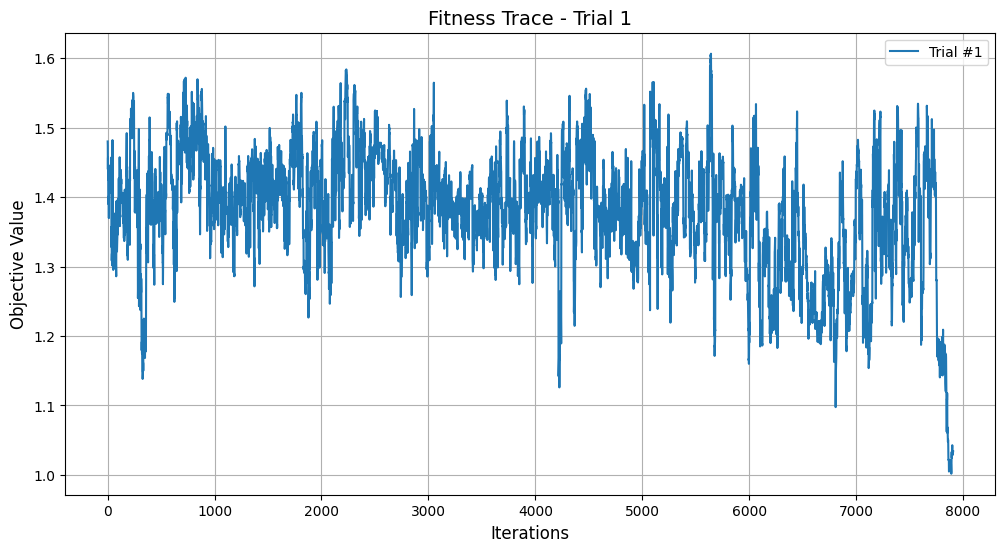

We estimate the Sharpe ratio to be 1.3810 ± 0.0877 under the posterior distribution of weights.


The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302


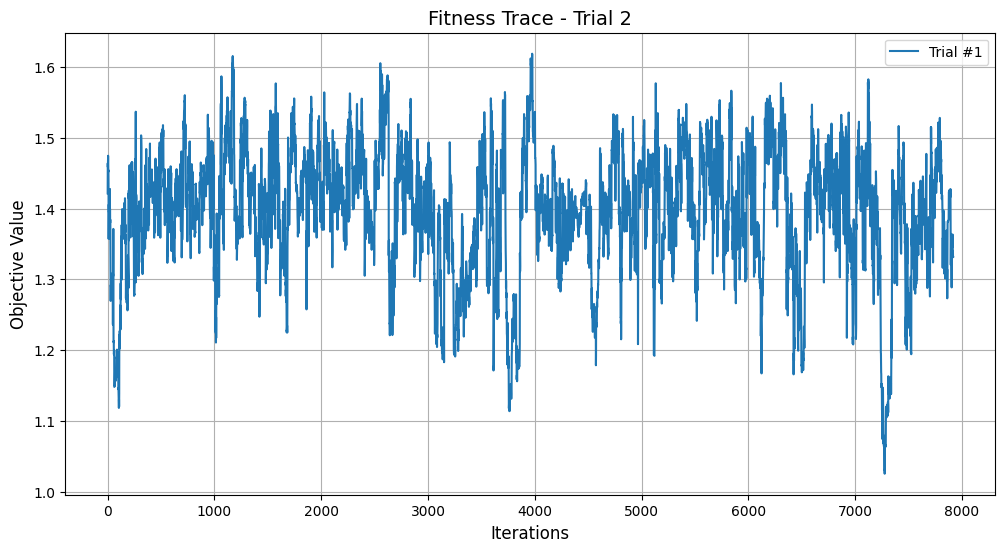

We estimate the Sharpe ratio to be 1.3967 ± 0.0893 under the posterior distribution of weights.


The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302


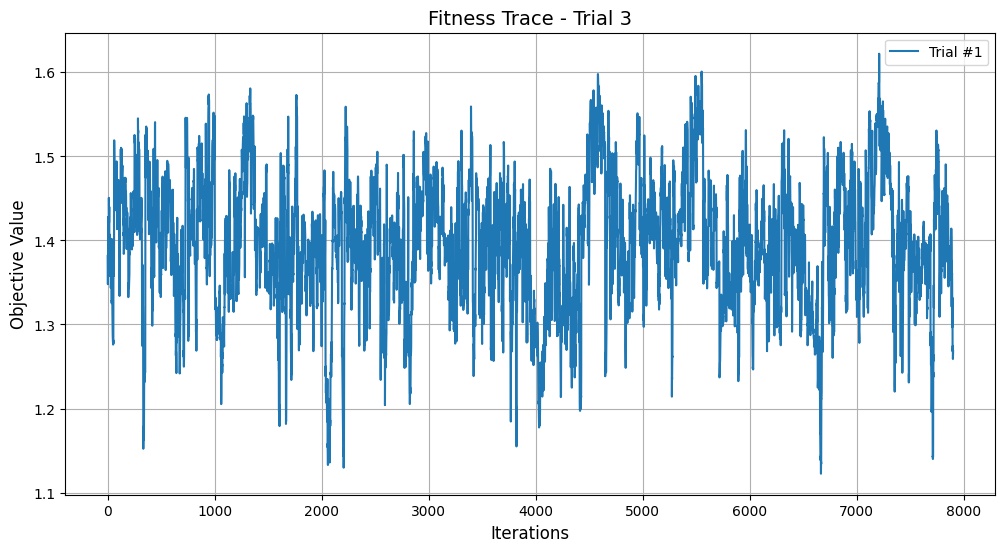

We estimate the Sharpe ratio to be 1.3963 ± 0.0780 under the posterior distribution of weights.


The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302


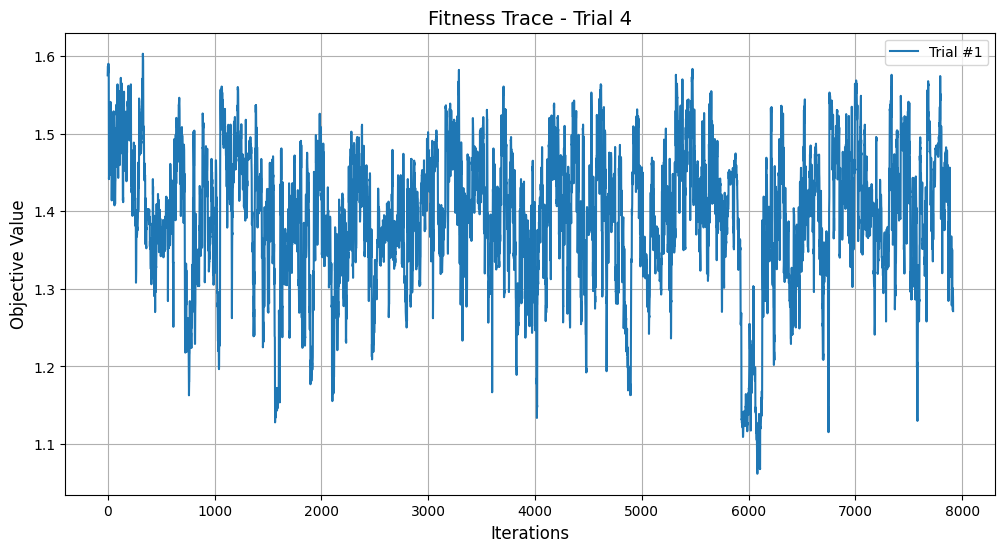

We estimate the Sharpe ratio to be 1.3925 ± 0.0893 under the posterior distribution of weights.


The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302


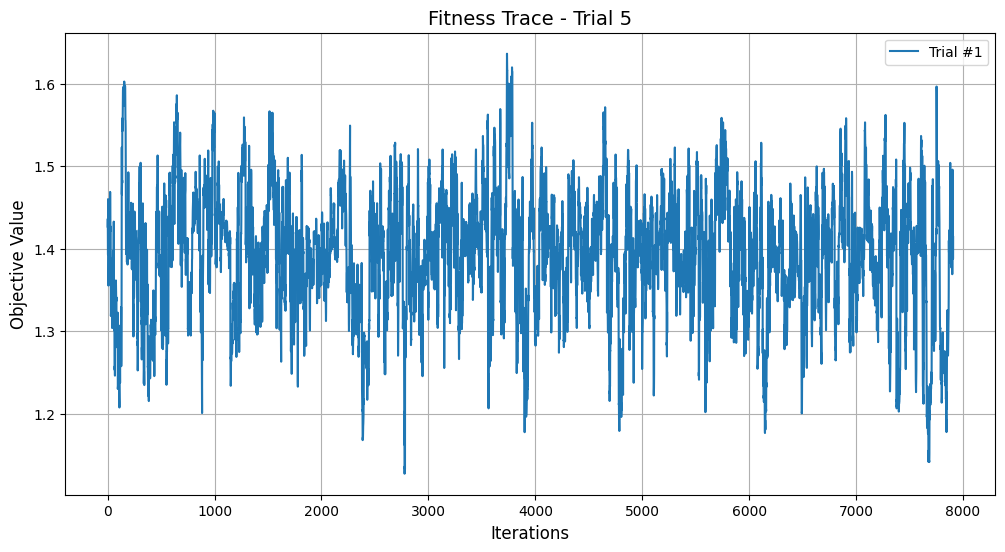

We estimate the Sharpe ratio to be 1.3934 ± 0.0753 under the posterior distribution of weights.



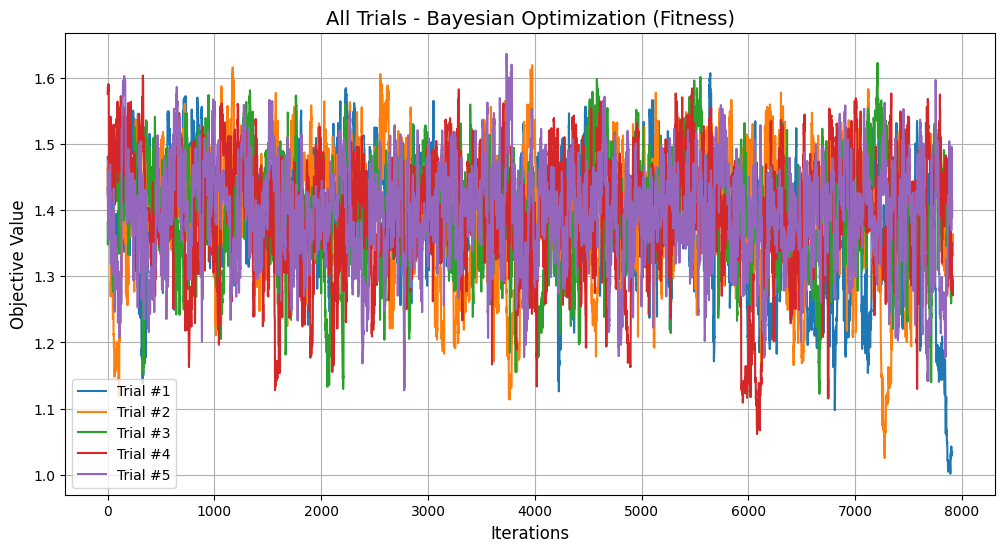

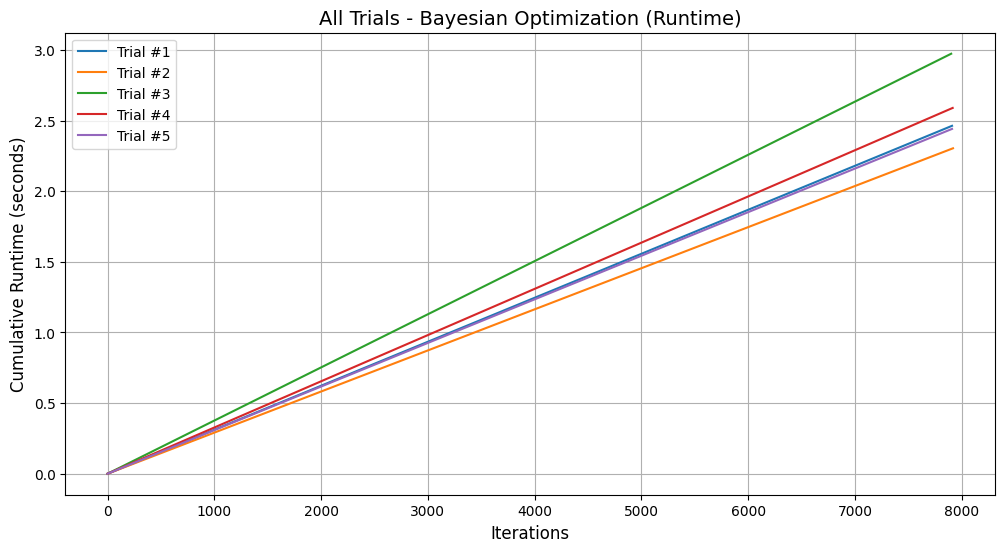

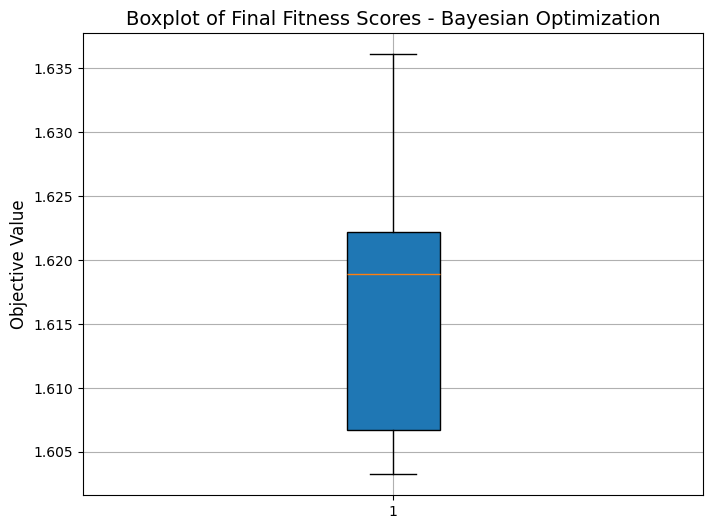


Trial Results Summary:
Optimization Method: Bayesian Optimization
Trial  Seed   Best_Score   Time_Taken (s)
--------------------------------------------------
1      1      1.6066873649527234 2.463555      
2      2      1.618883072024362 2.304384      
3      3      1.6221976744603215 2.973998      
4      4      1.6032507269025487 2.590175      
5      5      1.63609587482824 2.441568      

Trial 1:
We selected the top 0.01% of posterior portfolio samples based on Sharpe ratio. These portfolios exhibited Sharpe ratios between 1.589 and 1.607, offering a statistically grounded set of high-performing allocation strategies.
Each asset is bounded between 0.05 and 0.5, with VaR and CVaR of the solution required to be greater than 0.04774 and -0.01302, respectively

Top 1% Weights in trial 1:
[[0.05914302 0.08046218 0.09350943 0.13209088 0.06946173 0.06278768
  0.15218381 0.24272608 0.05196639 0.05566881]
 [0.05191837 0.08495322 0.09511511 0.14947351 0.05665498 0.05689909
  0.11925969 0.

In [35]:
if __name__ == "__main__":
    import time

    # Initialize the heuristic solver for Bayesian Optimization
    try:
        heuristic_solver = Heuristic(mean_returns, cov_matrix, mean_yield, len(mean_returns))
    except Exception as e:
        # Handle errors during initialization
        print(f"Error initializing Heuristic solver: {e}")
        exit(1)  # Exit if initialization fails

    # Set the number of trials and maximum iterations
    num_trials = 5
    max_iters = 10000
    alpha = 1.0  # Dirichlet prior parameter for Bayesian Optimization

    # Lists to store results for each trial
    fitness_traces = []
    runtime_traces = []
    final_scores = []
    trial_results = []
    all_sharpes = []
    all_volatilities = []
    all_weights = []
    all_run_time = []

    # Run the optimization process for a specified number of trials
    for trial in range(1, num_trials + 1):
        seed = trial
        np.random.seed(seed) # Set seed for reproducibility of results
        start_time = time.time() # Record the start time to calculate runtime

        try:
            # Call the Bayesian Optimization solver for the trial
            weights_trace, sharpe_trace, mean_sharpe, std_sharpe, best_score, best_weights, top_weights, top_sharpes, VaR_limit, CVaR_limit = heuristic_solver.solve_bayesian_optimization(
                heuristic_name="bayesian_optimization",
                mean_returns=mean_returns,
                cov_matrix=cov_matrix,
                risk_free_rate=mean_yield,
                n_iter=max_iters,
                alpha=alpha
            )
        except ValueError as ve:
            # Handle specific errors like ValueError
            print(f"ValueError during trial {trial}: {ve}")
            continue  # Skip this trial if a ValueError occurs

            # Handle specific errors like RuntimeError
        except RuntimeError as re:
            print(f"RuntimeError during trial {trial}: {re}")
            continue  # Skip this trial if a RuntimeError occurs
        except Exception as e:

            # Handle any other unexpected errors
            print(f"Unexpected error during trial {trial}: {e}")
            continue  # Skip this trial if any other unexpected error occurs

        end_time = time.time() # Record the end time after the trial is completed
        runtime = end_time - start_time # Calculate the trial runtime

        # Append trial results to corresponding lists
        fitness_traces.append(sharpe_trace)
        runtime_traces.append(np.linspace(0, runtime, len(sharpe_trace)))
        final_scores.append(best_score)
        trial_results.append((seed, best_score, runtime, top_weights, top_sharpes, VaR_limit, CVaR_limit))
        all_sharpes.append(best_score)
        all_volatilities.append(np.sqrt(best_weights.T @ cov_matrix @ best_weights))
        all_weights.append(best_weights)
        all_run_time.append(runtime)


        # Plot fitness trace for this specific trial
        try:
            Heuristic.plot_fitness_traces([sharpe_trace], f"Fitness Trace - Trial {trial}")
        except Exception as e:
            print(f"Error plotting fitness trace for trial {trial}: {e}")
            continue  # Skip plotting if error occurs

        print(f"We estimate the Sharpe ratio to be {mean_sharpe:.4f} ± {std_sharpe:.4f} under the posterior distribution of weights.")
        print("")

    # Summary plots for all trials
    try:
        Heuristic.plot_fitness_traces(fitness_traces, "All Trials - Bayesian Optimization (Fitness)")
    except Exception as e:
        print(f"Error plotting fitness trace summary: {e}")

    try:
        Heuristic.plot_runtime_trace(runtime_traces, "All Trials - Bayesian Optimization (Runtime)")
    except Exception as e:
        print(f"Error plotting runtime trace summary: {e}")

    try:
        Heuristic.plot_boxplot_fitness(final_scores, "Boxplot of Final Fitness Scores - Bayesian Optimization")
    except Exception as e:
        print(f"Error plotting boxplot of final fitness scores: {e}")

    # Convert to dict for compatibility with your table and comparison functions
    trial_results_dict = {"Bayesian Optimization": trial_results}
    fitness_traces_dict = {"Bayesian Optimization": fitness_traces}
    runtime_traces_dict = {"Bayesian Optimization": runtime_traces}

    # Print result table and comparison
    try:
        Heuristic.print_table_bayesian_optimization(trial_results_dict)
    except Exception as e:
        print(f"Error printing Bayesian optimization trial results: {e}")

    # Print a summary table for Bayesian Optimization results
    summary_bo = Heuristic.print_summary_table(
      all_sharpes=all_sharpes,
      all_volatilities=all_volatilities,
      all_weights=all_weights,
      returns=returns,
      asset_names=returns.columns,
      all_run_times = all_run_time,
      return_output=True
    )



In [31]:
if __name__ == "__main__":

    # Run multiple trials
    num_trials = 5
    population_size = 300
    generations = 1000
    num_assets = len(mean_returns)
    asset_names = returns.columns

    try:
        # Run the genetic optimization trials
        all_weights, all_metrics, all_cumulative_returns, all_runtime_traces = Heuristic.run_trials(
            num_trials=num_trials,
            population_size=population_size,
            generations=generations,
            mean_returns=mean_returns,
            cov_matrix=cov_matrix,
            mean_yield=mean_yield,
            num_assets=num_assets,
            asset_names=asset_names,
            returns=returns
        )
    except ValueError as ve:
        print(f"ValueError during trials execution: {ve}")
        exit(1)  # Exit if a ValueError occurs
    except RuntimeError as re:
        print(f"RuntimeError during trials execution: {re}")
        exit(1)  # Exit if a RuntimeError occurs
    except Exception as e:
        print(f"Unexpected error during trials execution: {e}")
        exit(1)  # Exit if any unexpected error occurs

    # Calculate summary statistics
    try:
        mean_sharpe = np.mean([metric[0] for metric in all_metrics])
        std_sharpe = np.std([metric[0] for metric in all_metrics])
        mean_cumulative = np.mean(all_cumulative_returns)
        std_cumulative = np.std(all_cumulative_returns)
        mean_volatility = np.mean([metric[2] for metric in all_metrics])
        std_volatility = np.std([metric[2] for metric in all_metrics])
        # Extract final runtime from each trial
        all_run_time = [trace[-1] for trace in all_runtime_traces]
        mean_all_run_time = np.mean(all_run_time)
        std_all_run_time = np.std(all_run_time)


        # Print summary statistics
        print("\nSummary Statistics:")
        print(f"Sharpe Ratio: {mean_sharpe:.4f} ± {std_sharpe:.4f}")
        print(f"Cumulative Return: {mean_cumulative:.2%} ± {std_cumulative:.2%}")
        print(f"Volatility (Risk): {mean_volatility:.2%} ± {std_volatility:.2%}")
        print(f"Runtime (seconds): {mean_all_run_time:.2f} ± {std_all_run_time:.2f}")
    except Exception as e:
        print(f"Error calculating summary statistics: {e}")
        exit(1)  # Exit if an error occurs in the calculation

    summary_ga = {
        "mean_sharpe": np.mean([metric[0] for metric in all_metrics]),
        "std_sharpe": np.std([metric[0] for metric in all_metrics]),
        "mean_volatility": np.mean([metric[2] for metric in all_metrics]),
        "std_volatility": np.std([metric[2] for metric in all_metrics]),
        "mean_cumulative_return": np.mean(all_cumulative_returns),
        "std_cumulative_return": np.std(all_cumulative_returns),
        "mean_runtime": np.mean(all_run_time),
        "std_runtime": np.std(all_run_time)
    }

    # Print summary table
    try:
        print("\nTrial Results Summary:")
        print(f"{'Trial':<6} {'Sharpe Ratio':<15} {'Cumulative Return':<20} {'Volatility':<15} {'Time_Taken (s)':<14}")
        print("-" * 70)
        for i, (metric, cumulative, runtime) in enumerate(zip(all_metrics, all_cumulative_returns, all_runtime_traces), 1):
            print(f"{i:<6} {metric[0]:<15.4f} {cumulative:<20.2%} {metric[2]:<15.2%} {runtime[-1]:<14.4f}")
    except Exception as e:
        print(f"Error printing trial results table: {e}")
        exit(1)  # Exit if an error occurs while printing results


KeyboardInterrupt: 

The limit of VaR we selected here is: 0.05387
The limit of CVaR we selected here is: -0.02646


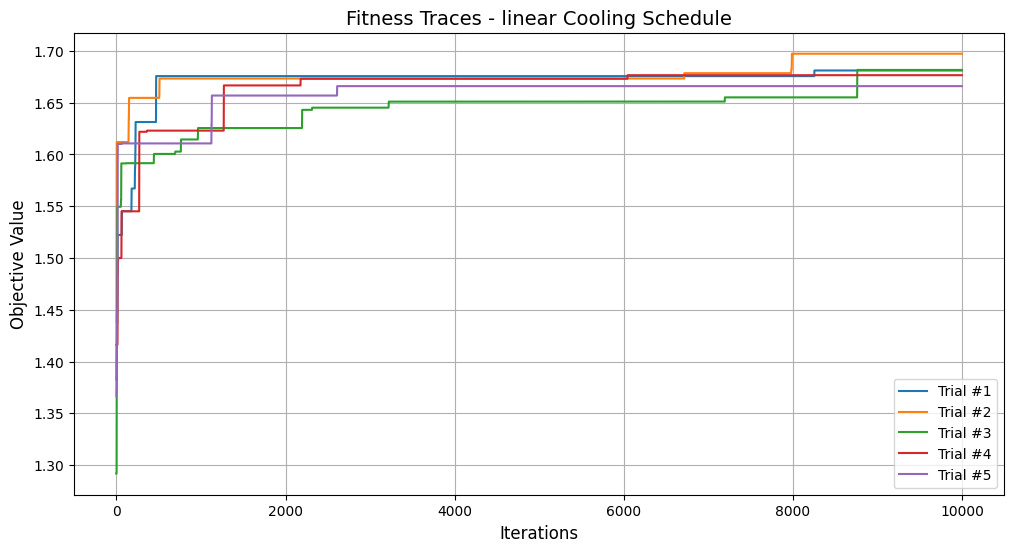

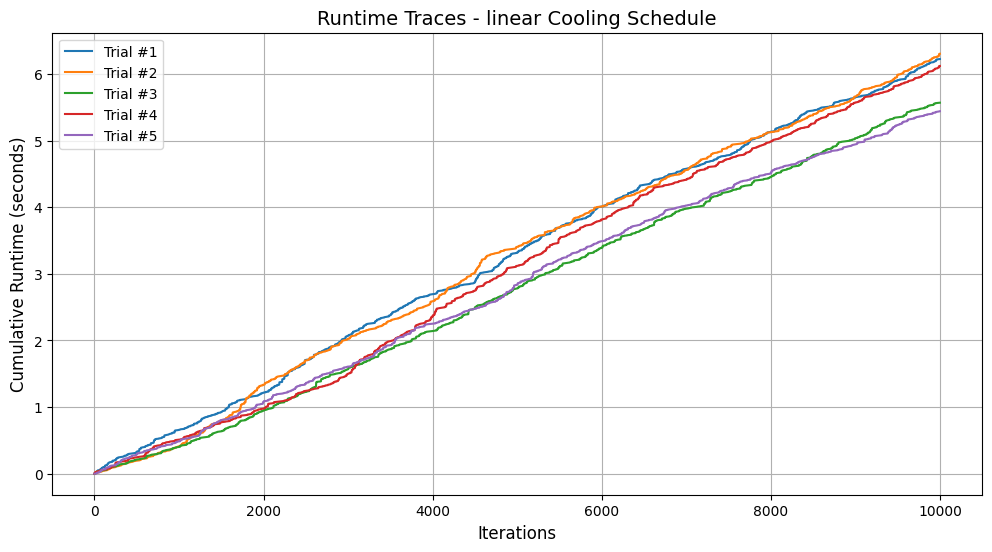

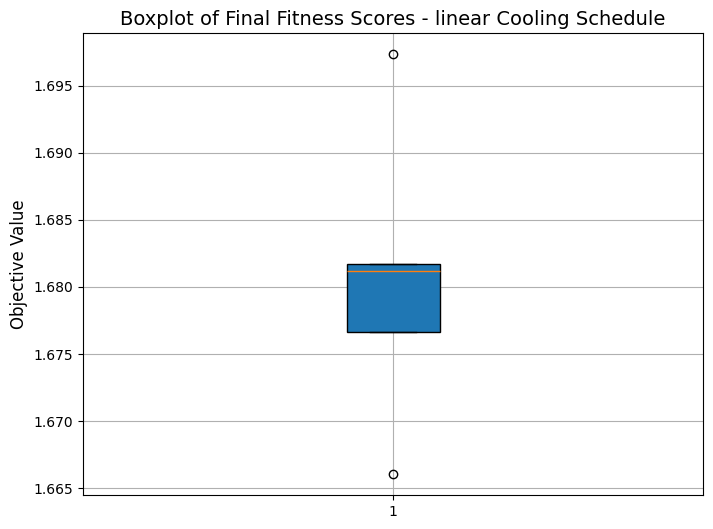


Trial Results Summary:
Trial  Sharpe Ratio    Cumulative Return    Volatility      Runtime (s)    
------------------------------------------------------------------------------------------
1      1.6812          16600.03%            23.66%          6.22           
2      1.6973          15568.50%            23.05%          6.30           
3      1.6817          16040.05%            23.46%          5.57           
4      1.6766          15805.75%            23.46%          6.12           
5      1.6660          15671.28%            23.57%          5.44           

Summary Statistics:
Sharpe Ratio:        1.6806 ± 0.0101
Cumulative Return:   15937.12% ± 367.11%
Volatility (Risk):   23.44% ± 0.21%
Runtime (seconds):   5.93 ± 0.36


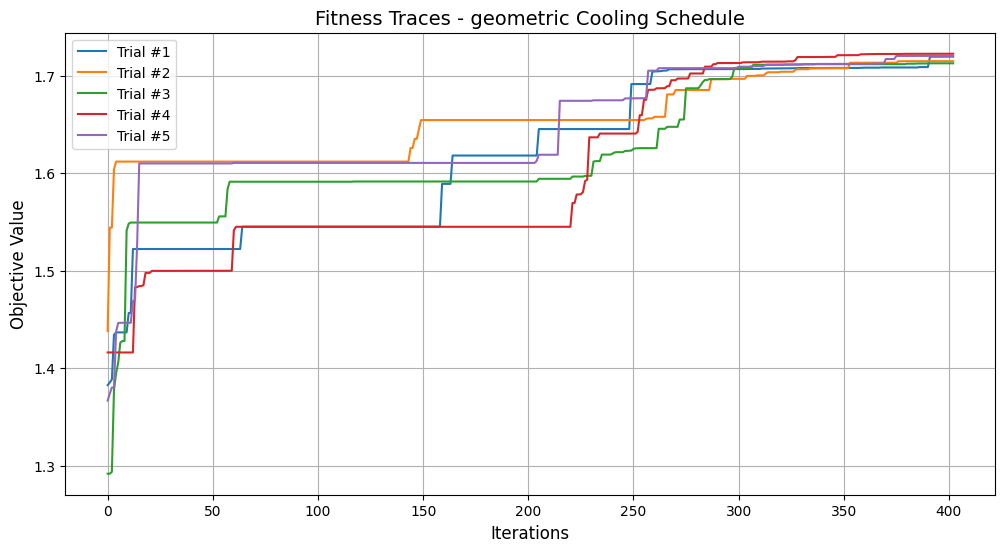

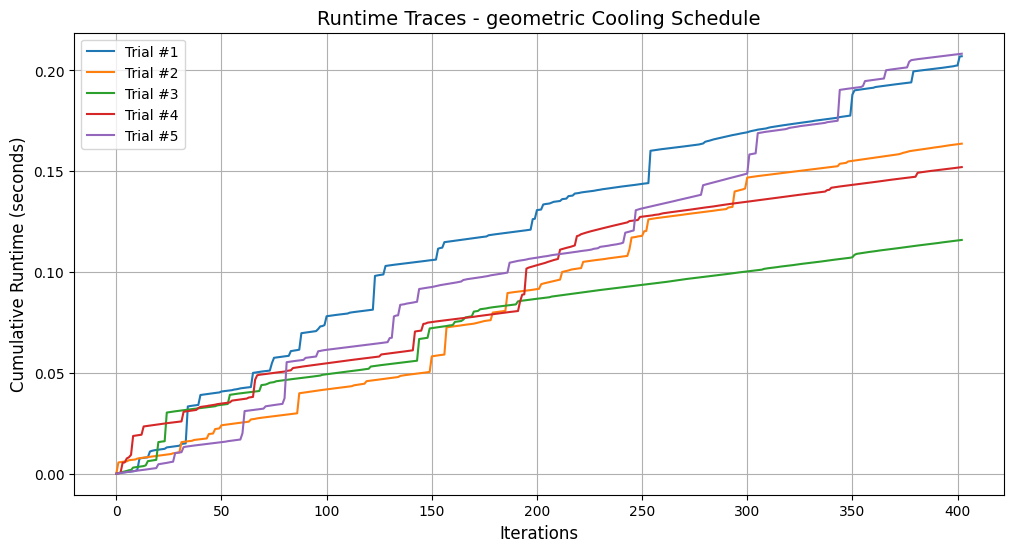

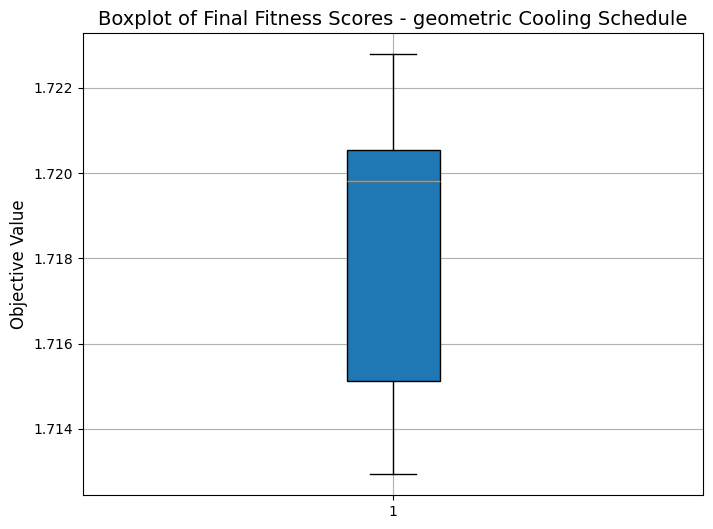


Trial Results Summary:
Trial  Sharpe Ratio    Cumulative Return    Volatility      Runtime (s)    
------------------------------------------------------------------------------------------
1      1.7198          14773.13%            22.42%          0.21           
2      1.7151          15764.32%            22.85%          0.16           
3      1.7129          16318.28%            23.08%          0.12           
4      1.7228          15169.99%            22.53%          0.15           
5      1.7205          15194.73%            22.57%          0.21           

Summary Statistics:
Sharpe Ratio:        1.7182 ± 0.0036
Cumulative Return:   15444.09% ± 539.31%
Volatility (Risk):   22.69% ± 0.24%
Runtime (seconds):   0.17 ± 0.03


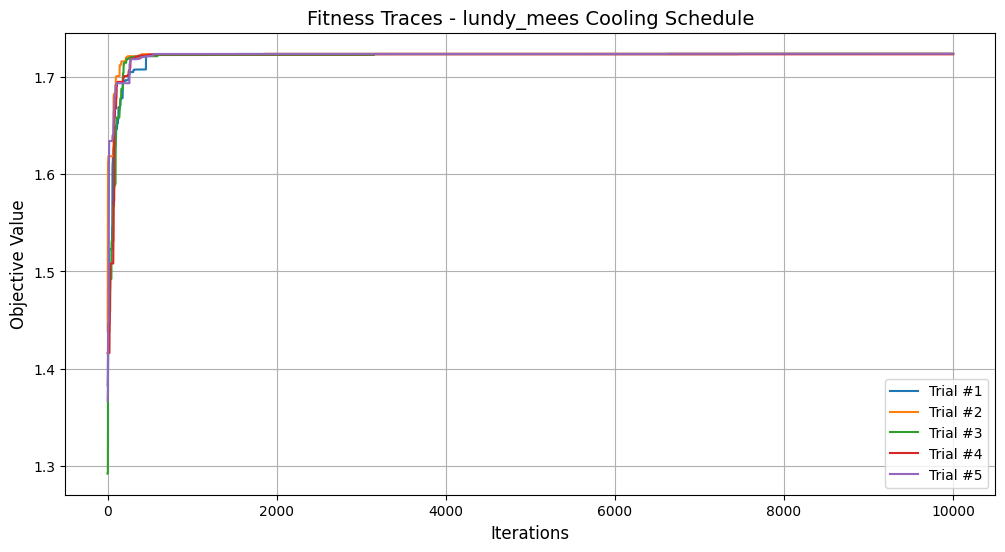

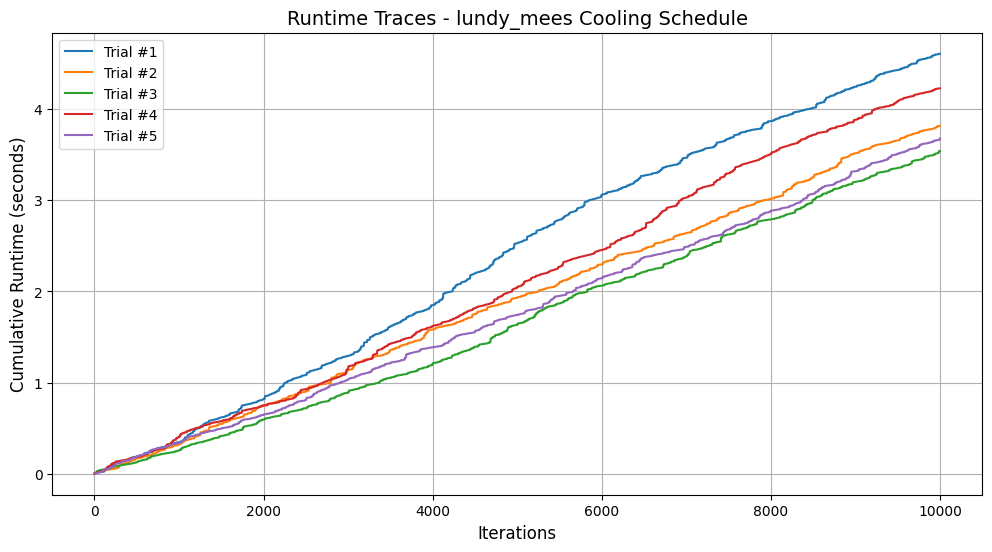

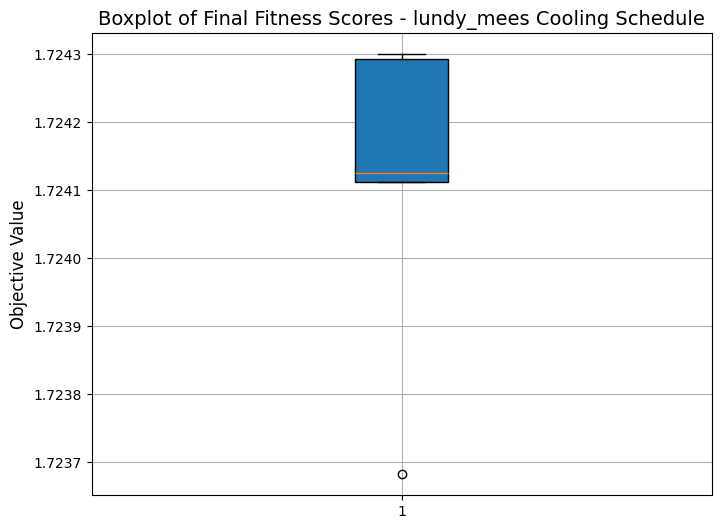


Trial Results Summary:
Trial  Sharpe Ratio    Cumulative Return    Volatility      Runtime (s)    
------------------------------------------------------------------------------------------
1      1.7241          15323.21%            22.56%          4.61           
2      1.7243          15191.08%            22.51%          3.82           
3      1.7241          15339.77%            22.57%          3.54           
4      1.7237          15444.11%            22.61%          4.23           
5      1.7243          15244.80%            22.53%          3.68           

Summary Statistics:
Sharpe Ratio:        1.7241 ± 0.0002
Cumulative Return:   15308.60% ± 86.52%
Volatility (Risk):   22.56% ± 0.03%
Runtime (seconds):   3.97 ± 0.39


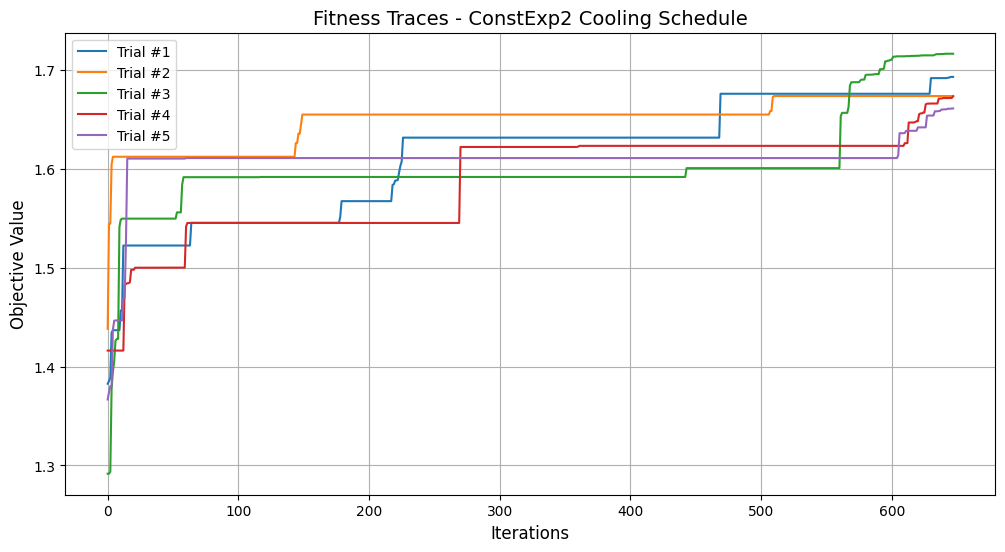

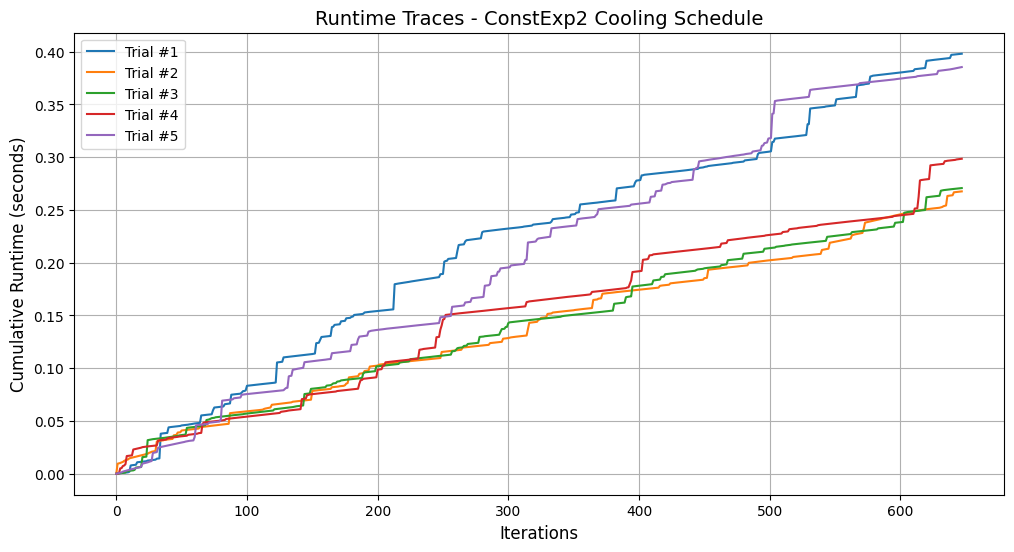

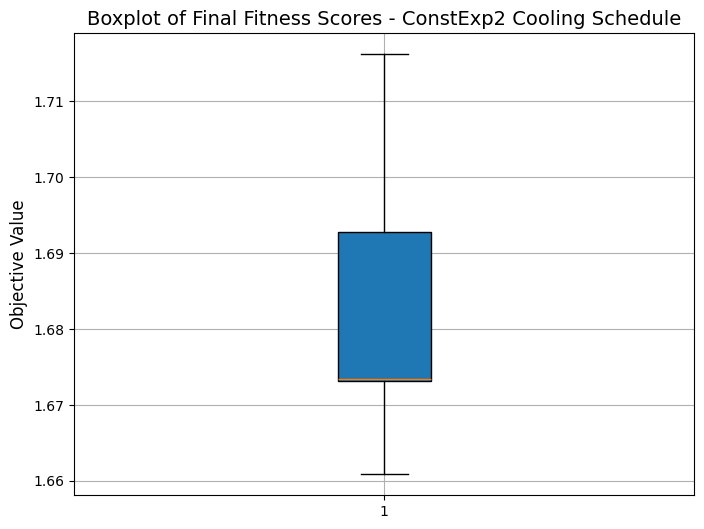


Trial Results Summary:
Trial  Sharpe Ratio    Cumulative Return    Volatility      Runtime (s)    
------------------------------------------------------------------------------------------
1      1.6928          14961.80%            22.90%          0.40           
2      1.6734          14100.56%            22.85%          0.27           
3      1.7162          15816.14%            22.86%          0.27           
4      1.6732          17161.50%            23.98%          0.30           
5      1.6609          17187.91%            24.18%          0.39           

Summary Statistics:
Sharpe Ratio:        1.6833 ± 0.0194
Cumulative Return:   15845.58% ± 1213.30%
Volatility (Risk):   23.35% ± 0.60%
Runtime (seconds):   0.32 ± 0.06

Trial Results Summary:
Schedule        Trial  Seed   Best_Score   Time_Taken (s)
--------------------------------------------------
linear          1      1      1.6811579651455089 6.223232      
linear          2      2      1.6973459012344743 6.302785      

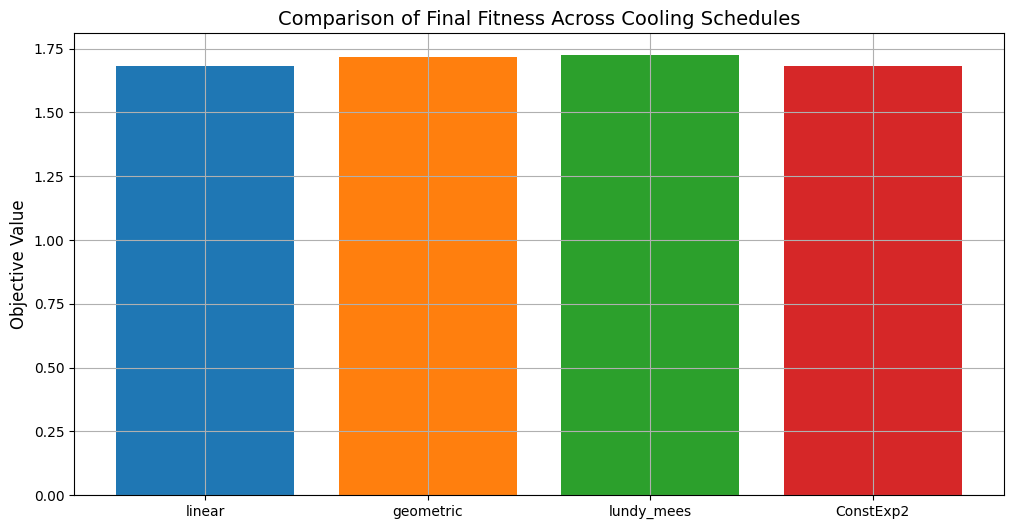

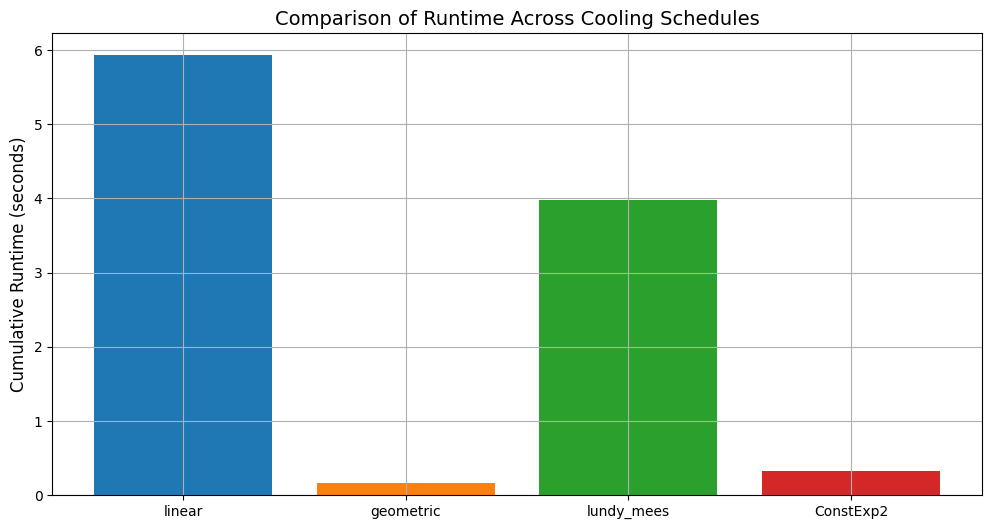


=== Final Summary Across All Cooling Schedules ===

Cooling Schedule: linear
Mean Sharpe Ratio     : 1.6806 ± 0.0101
Mean Volatility       : 23.44% ± 0.21%
Mean Cumulative Return: 15937.12% ± 367.11%
Mean Cumulative Return: 15937.12% ± 367.11%
Mean Runtime (s)      : 5.93 ± 0.36

Cooling Schedule: geometric
Mean Sharpe Ratio     : 1.7182 ± 0.0036
Mean Volatility       : 22.69% ± 0.24%
Mean Cumulative Return: 15444.09% ± 539.31%
Mean Cumulative Return: 15444.09% ± 539.31%
Mean Runtime (s)      : 0.17 ± 0.03

Cooling Schedule: lundy_mees
Mean Sharpe Ratio     : 1.7241 ± 0.0002
Mean Volatility       : 22.56% ± 0.03%
Mean Cumulative Return: 15308.60% ± 86.52%
Mean Cumulative Return: 15308.60% ± 86.52%
Mean Runtime (s)      : 3.97 ± 0.39

Cooling Schedule: ConstExp2
Mean Sharpe Ratio     : 1.6833 ± 0.0194
Mean Volatility       : 23.35% ± 0.60%
Mean Cumulative Return: 15845.58% ± 1213.30%
Mean Cumulative Return: 15845.58% ± 1213.30%
Mean Runtime (s)      : 0.32 ± 0.06


In [ ]:
if __name__ == "__main__":

    try:
        # Initialize the heuristic solver
        heuristic_solver = Heuristic(mean_returns, cov_matrix, mean_yield, len(mean_returns))
    except Exception as e:
        print(f"Error initializing heuristic solver: {e}")
        exit(1)

    # Define cooling schedules etc.
    schedules = ["linear", "geometric", "lundy_mees", "ConstExp2"]
    num_trials = 5
    max_iters = 10000
    alpha = 0.95
    beta = 0.95
    initial_temp = 900

    # Initialize result storage
    fitness_traces_dict = {}  # A dictionary where the keys are the names of the cooling schedules (e.g., 'Exponential', 'Linear'), and the values are lists of fitness traces (lists of fitness values over time for multiple runs of the algorithm).
    runtime_traces_dict = {}  # A dictionary where the keys are the names of the cooling schedules, and the values are lists of runtime traces (cumulative runtimes over time for multiple runs of the algorithm).
    final_scores_dict = {}
    trial_results = {}
    final_summary = {}
    summary_sa = {}

    for schedule in schedules:
        fitness_traces = []
        runtime_traces = []
        final_scores = []
        results = []
        all_sharpes = []
        all_volatilities = []
        all_weights = []

        for trial in range(1, num_trials + 1):
            seed = trial
            try:
                # Run simulated annealing for each trial
                results_trial = heuristic_solver.solve_simulated_annealing(
                    heuristic_name="simulated_annealing",
                    max_iters=max_iters,
                    seed=seed,
                    schedule=schedule,
                    alpha=alpha,
                    beta=beta,
                    initial_temp=initial_temp
                )
                best_solution, best_score, scores, times, runtime = results_trial

                fitness_traces.append(scores)
                runtime_traces.append(times)
                final_scores.append(best_score)
                results.append((seed, best_score, runtime))
                all_sharpes.append(best_score)
                all_volatilities.append(np.sqrt(best_solution.T @ cov_matrix @ best_solution))
                all_weights.append(best_solution)

            except Exception as e:
                print(f"Error during trial {trial} with schedule {schedule}: {e}")
                continue  # Skip to the next trial in case of error

        # Store results for each cooling schedule
        fitness_traces_dict[schedule] = fitness_traces
        runtime_traces_dict[schedule] = runtime_traces
        final_scores_dict[schedule] = final_scores
        trial_results[schedule] = results
        total_runtimes = [trace[-1] for trace in runtime_traces]  # Extract final runtime for each trial

        # Calculate cumulative returns for this schedule
        cumulative_returns = [(1 + np.dot(returns, w)).prod() - 1 for w in all_weights]
        # Save stats to final_summary
        final_summary[schedule] = {
            "sharpes": all_sharpes,
            "volatilities": all_volatilities,
            "cumulative_returns": cumulative_returns,
            "runtimes": total_runtimes
                      }
        for schedule, data in final_summary.items():
          summary_sa[schedule] = {
              "mean_sharpe": np.mean(data['sharpes']),
              "std_sharpe": np.std(data['sharpes']),
              "mean_volatility": np.mean(data['volatilities']),
              "std_volatility": np.std(data['volatilities']),
              "mean_cumulative_return": np.mean(data['cumulative_returns']),
              "std_cumulative_return": np.std(data['cumulative_returns']),
              "mean_runtime": np.mean(data['runtimes']),
              "std_runtime": np.std(data['runtimes'])
          }

        try:
            # Plot separate charts for each schedule
            Heuristic.plot_fitness_traces(fitness_traces, f"Fitness Traces - {schedule} Cooling Schedule")
            Heuristic.plot_runtime_trace(runtime_traces, f"Runtime Traces - {schedule} Cooling Schedule")
            Heuristic.plot_boxplot_fitness(final_scores, f"Boxplot of Final Fitness Scores - {schedule} Cooling Schedule")
        except Exception as e:
            print(f"Error plotting results for schedule {schedule}: {e}")
            continue  # Skip to the next schedule if an error occurs in plotting

        # Print Summary Table
        Heuristic.print_summary_table(
          all_sharpes=all_sharpes,
          all_volatilities=all_volatilities,
          all_weights=all_weights,
          returns=returns,
          all_run_times=total_runtimes,
          asset_names=returns.columns
        )

    try:
        # Print table of trial results
        Heuristic.print_table_simulated_annealing(trial_results)
    except Exception as e:
        print(f"Error printing trial results table: {e}")
        exit(1)

    try:
        # Plot comparisons across cooling schedules
        Heuristic.plot_comparison(fitness_traces_dict, runtime_traces_dict)
    except Exception as e:
        print(f"Error plotting comparison: {e}")
        exit(1)

    # Summarize all cooling schedules
    print("\n=== Final Summary Across All Cooling Schedules ===")

    for schedule, data in final_summary.items():
        mean_sr = np.mean(data['sharpes'])
        std_sr = np.std(data['sharpes'])
        mean_vol = np.mean(data['volatilities'])
        std_vol = np.std(data['volatilities'])
        mean_cumret = np.mean(data['cumulative_returns'])
        std_cumret = np.std(data['cumulative_returns'])
        mean_rt = np.mean(data['runtimes'])
        std_rt = np.std(data['runtimes'])

        print(f"\nCooling Schedule: {schedule}")
        print(f"Mean Sharpe Ratio     : {mean_sr:.4f} ± {std_sr:.4f}")
        print(f"Mean Volatility       : {mean_vol:.2%} ± {std_vol:.2%}")
        print(f"Mean Cumulative Return: {mean_cumret:.2%} ± {std_cumret:.2%}")
        print(f"Mean Cumulative Return: {mean_cumret:.2%} ± {std_cumret:.2%}")
        print(f"Mean Runtime (s)      : {mean_rt:.2f} ± {std_rt:.2f}")





The limit of VaR we selected here is: 0.04840
The limit of CVaR we selected here is: -0.01527

✅ Best Portfolio Found with Auto-Tuned VaR/CVaR Limits:
  Asset    Weight
0  AVGO  0.050000
1  AXON  0.050000
2   DPZ  0.164049
3  FICO  0.050000
4  NFLX  0.050000
5  NVDA  0.050000
6   TDG  0.253493
7   TPL  0.232458
8  TSLA  0.050000
9   URI  0.050000

Portfolio Expected Return: 41.35%
Portfolio Risk (Std. Dev): 22.44%
Sharpe Ratio: 1.7236


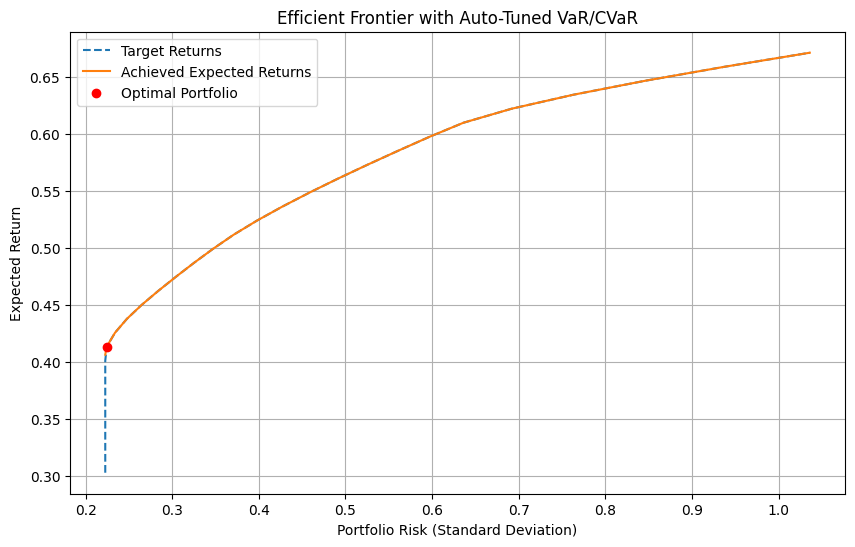

In [22]:
if __name__ == "__main__":

    try:
        # Initialize the heuristic solver for mean-variance optimization
        heuristic_solver = Heuristic(mean_returns, cov_matrix, mean_yield, len(mean_returns))
    except Exception as e:
        print(f"Error initializing heuristic solver: {e}")
        exit(1)

    try:
        # Solve the mean-variance optimization problem
        heuristic_solver.solve_mean_variance(
            heuristic_name="mean_variance_optimization",
        )
    except Exception as e:
        print(f"Error solving mean-variance optimization: {e}")
        exit(1)


In [ ]:
print("\n=== Final Summary Comparison: GA, BO, SA ===")

# Print Genetic Algorithm Summary
print("\n[Genetic Algorithm (GA)]")
print(f"Mean Sharpe Ratio     : {summary_ga['mean_sharpe']:.4f} ± {summary_ga['std_sharpe']:.4f}")
print(f"Mean Volatility       : {summary_ga['mean_volatility']:.2%} ± {summary_ga['std_volatility']:.2%}")
print(f"Mean Cumulative Return: {summary_ga['mean_cumulative_return']:.2%} ± {summary_ga['std_cumulative_return']:.2%}")
print(f"Mean Runtime (s)      : {summary_ga['mean_runtime']:.2f} ± {summary_ga['std_runtime']:.2f}")

# Print Bayesian Optimization Summary
print("\n[Bayesian Optimization (BO)]")
print(f"Mean Sharpe Ratio     : {summary_bo['mean_sharpe']:.4f} ± {summary_bo['std_sharpe']:.4f}")
print(f"Mean Volatility       : {summary_bo['mean_volatility']:.2%} ± {summary_bo['std_volatility']:.2%}")
print(f"Mean Cumulative Return: {summary_bo['mean_cumulative_return']:.2%} ± {summary_bo['std_cumulative_return']:.2%}")
print(f"Mean Runtime (s)      : {summary_bo['mean_runtime']:.2f} ± {summary_bo['std_runtime']:.2f}")

# Print Simulated Annealing Summaries by Cooling Schedule
print("\n[Simulated Annealing (SA) - Cooling Schedules]")
for schedule, stats in summary_sa.items():
    print(f"\nCooling Schedule: {schedule}")
    print(f"Mean Sharpe Ratio     : {stats['mean_sharpe']:.4f} ± {stats['std_sharpe']:.4f}")
    print(f"Mean Volatility       : {stats['mean_volatility']:.2%} ± {stats['std_volatility']:.2%}")
    print(f"Mean Cumulative Return: {stats['mean_cumulative_return']:.2%} ± {stats['std_cumulative_return']:.2%}")
    print(f"Mean Runtime (s)      : {stats['mean_runtime']:.2f} ± {stats['std_runtime']:.2f}")




=== Final Summary Comparison: GA, BO, SA ===

[Genetic Algorithm (GA)]
Mean Sharpe Ratio     : 1.7391 ± 0.0161
Mean Volatility       : 22.46% ± 0.37%
Mean Cumulative Return: 15629.40% ± 504.42%
Mean Runtime (s)      : 4.65 ± 0.39

[Bayesian Optimization (BO)]
Mean Sharpe Ratio     : 1.5314 ± 0.0442
Mean Volatility       : 26.78% ± 0.80%
Mean Cumulative Return: 17926.12% ± 830.14%
Mean Runtime (s)      : 0.12 ± 0.02

[Simulated Annealing (SA) - Cooling Schedules]

Cooling Schedule: linear
Mean Sharpe Ratio     : 1.5859 ± 0.0230
Mean Volatility       : 25.52% ± 0.28%
Mean Cumulative Return: 17332.97% ± 603.72%
Mean Runtime (s)      : 0.11 ± 0.02

Cooling Schedule: geometric
Mean Sharpe Ratio     : 1.5922 ± 0.0314
Mean Volatility       : 25.28% ± 0.46%
Mean Cumulative Return: 16985.27% ± 578.61%
Mean Runtime (s)      : 0.10 ± 0.02

Cooling Schedule: lundy_mees
Mean Sharpe Ratio     : 1.6995 ± 0.0203
Mean Volatility       : 23.15% ± 0.80%
Mean Cumulative Return: 15965.72% ± 1509.78%
Mean 


The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302

The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302

The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302

The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302

The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302

The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302

The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302

The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302

The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302

The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302

The limit of VaR we selected here is: 0.04774
The

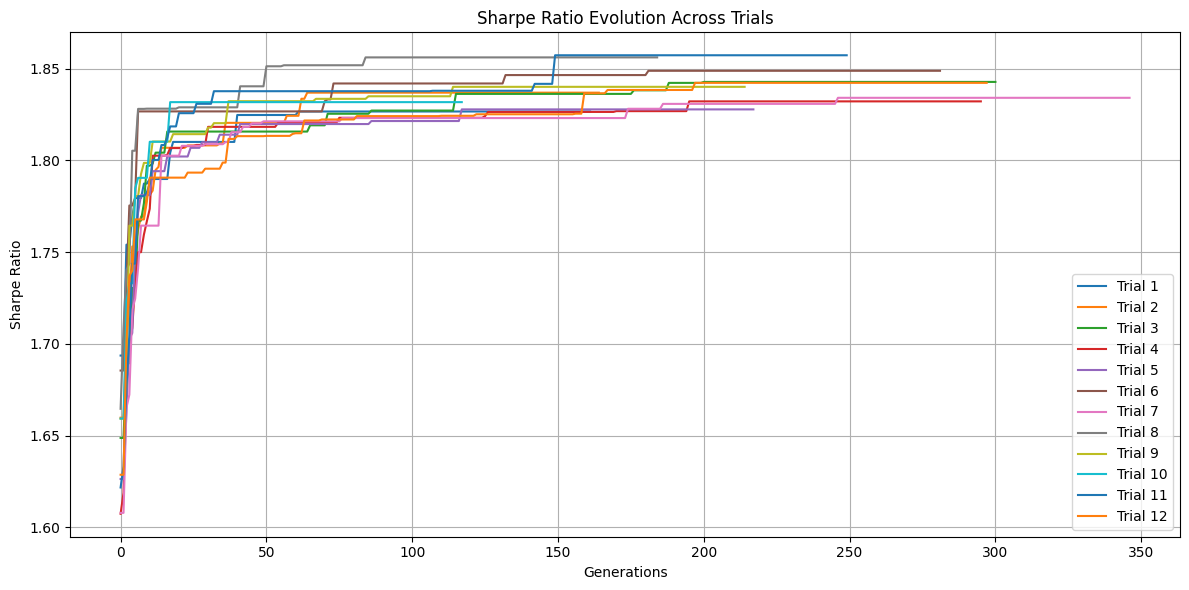

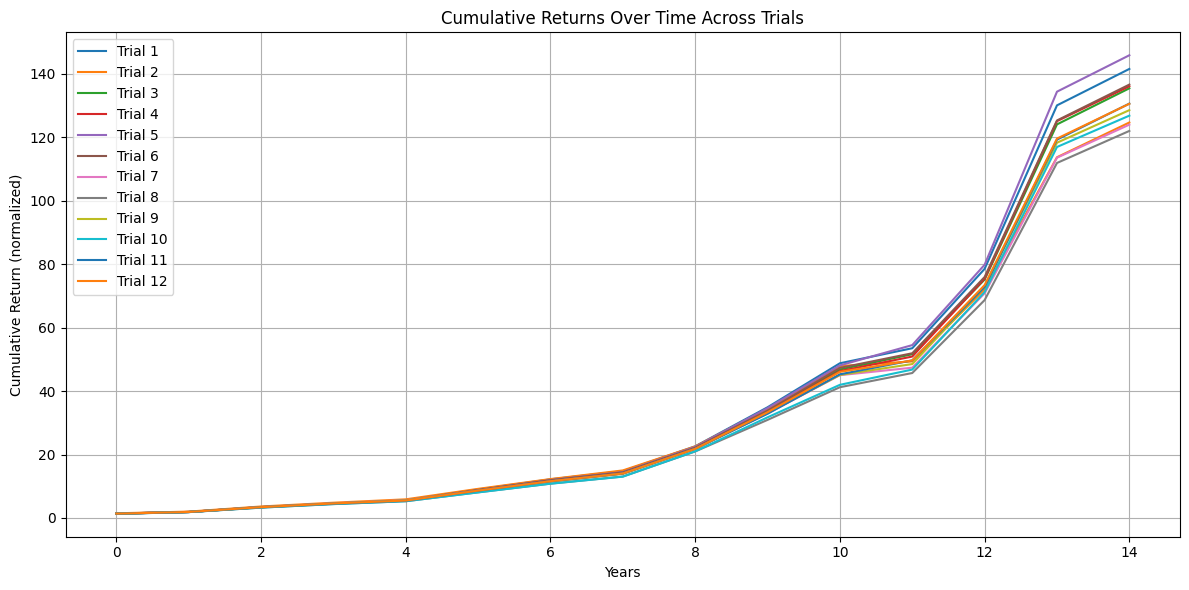

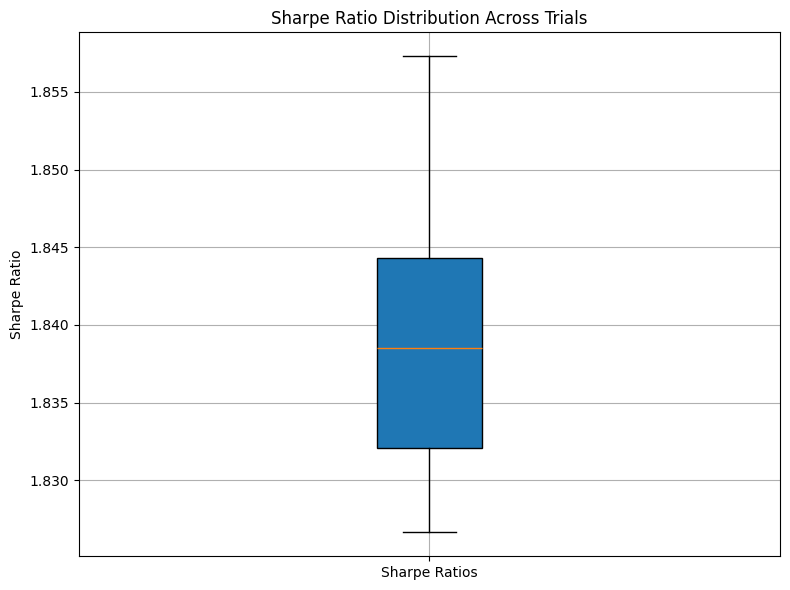


The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302

The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302

The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302

The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302

The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302

The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302

The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302

The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302

The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302

The limit of VaR we selected here is: 0.04774
The limit of CVaR we selected here is: -0.01302

The limit of VaR we selected here is: 0.04774
The

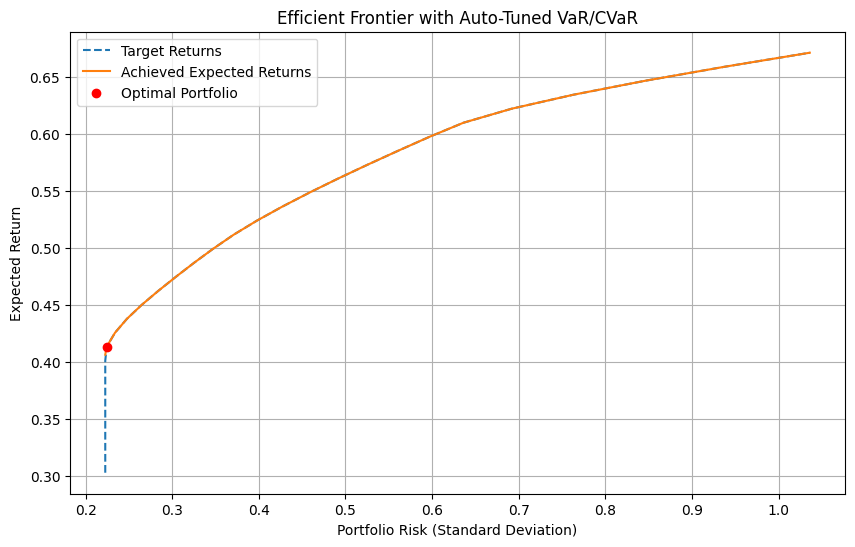


Performing Wilcoxon Signed-Rank Tests...

=== Wilcoxon Signed-Rank Test Results (Pairwise Comparison) ===

Wilcoxon Signed-Rank Test Pairwise Comparison Results:
                     Algorithm 1                      Algorithm 2  N (Valid Pairs) Wilcoxon Stat (W) P-value          Significance (alpha=0.05)
           Bayesian Optimization                Genetic Algorithm               12            0.0000  0.0005 Reject H0 (Significant Difference)
           Bayesian Optimization Simulated Annealing (Lundy-Mees)               12            0.0000  0.0005 Reject H0 (Significant Difference)
           Bayesian Optimization       Mean Variance Optimization               12            0.0000  0.0005 Reject H0 (Significant Difference)
               Genetic Algorithm Simulated Annealing (Lundy-Mees)               12            0.0000  0.0005 Reject H0 (Significant Difference)
               Genetic Algorithm       Mean Variance Optimization               12            0.0000  0.0005 Reject H

In [36]:
# === Perform Wilcoxon Test ===

# Warning: This section might take a long time to run
# This section performs repeated trials for different portfolio optimization heuristics:
# Bayesian Optimization (BO), Genetic Algorithm (GA), Simulated Annealing (SA), and Mean-Variance Optimization (MVO).
# Each method is executed across `n_trials`, and their best Sharpe ratios are collected.

# === Experiment Configuration ===
n_trials = 12  # Number of independent trials for each optimization method

# === Simulated Annealing (SA) Parameters ===
max_iters_SA = 10000
alpha_SA = 0.95
beta = 0.95
initial_temp = 900

# === Bayesian Optimization (BO) Parameters ===
max_iters_BO = 10000
alpha_BO = 1.0

# === Genetic Algorithm (GA) Parameters ===
population_size = 300
generations = 1000

# === Portfolio Information ===
num_assets = len(mean_returns)
asset_names = returns.columns

# === Storage for Best Sharpe Ratios ===
bo_sharpes = []  # Bayesian Optimization
ga_sharpes = []  # Genetic Algorithm
sa_sharpes = []  # Simulated Annealing
final_scores_dict = {}  # Optional: to store scores for summary/statistics

heuristic_solver = Heuristic(mean_returns, cov_matrix, mean_yield, len(mean_returns))
# Bayesian Optimization: collect best Sharpe ratios from each trial
for trials in range(n_trials):
  seed = trials # ensure different seed per trial
  np.random.seed(seed)
  weights_trace, sharpe_trace, mean_sharpe, std_sharpe, best_score, best_weights, top_weights, top_sharpes, VaR_limit, CVaR_limit = heuristic_solver.solve_bayesian_optimization(
      heuristic_name="bayesian_optimization",
      mean_returns=mean_returns,
      cov_matrix=cov_matrix,
      risk_free_rate=mean_yield,
      n_iter=max_iters_BO,
      alpha=alpha_BO
  )
  bo_sharpes.append(best_score)

# Genetic Algorithm: collect best Sharpe ratios using pre-defined utility function
all_weights, all_metrics, all_cumulative_returns, all_runtime_traces = Heuristic.run_trials(
    num_trials=n_trials,
    population_size=population_size,
    generations=generations,
    mean_returns=mean_returns,
    cov_matrix=cov_matrix,
    mean_yield=mean_yield,
    num_assets=num_assets,
    asset_names=asset_names,
    returns=returns
)
ga_sharpes = [metric[0] for metric in all_metrics]

# Simulated Annealing (SA): Repeated Trials
final_scores = []
for trials in range(n_trials):
  seed = trials # ensure different seed per trial
  results_trial = heuristic_solver.solve_simulated_annealing(
                      heuristic_name="simulated_annealing",
                      max_iters=max_iters_SA,
                      seed=seed,
                      schedule="lundy_mees",
                      alpha=alpha_SA,
                      beta=beta,
                      initial_temp=initial_temp
                  )
  best_solution, best_score, scores, times, runtime = results_trial
  final_scores.append(best_score)
sa_sharpes = final_scores

# Simulated Annealing (SA): Repeated Trials
mean_variance_sharpe = heuristic_solver.solve_mean_variance(
            heuristic_name="mean_variance_optimization",
        )
mvo_sharpes = [mean_variance_sharpe] * n_trials

print(f"\nPerforming Wilcoxon Signed-Rank Tests...")

# Prepare the dictionary for the Wilcoxon test using the collected sharpe lists.
# These lists should now have length num_trials, potentially with NaNs for failed trials.
# === Prepare Data for Wilcoxon Test ===
all_algorithm_sharpes = {}

# Only include algorithms in the Wilcoxon test if their primary results list is not empty
if bo_sharpes:
    all_algorithm_sharpes["Bayesian Optimization"] = bo_sharpes

if ga_sharpes:
    # ga_sharpes from run_trials now only contains valid results, so pad it back to num_trials length
    padded_ga_sharpes = ga_sharpes + [np.nan] * (num_trials - len(ga_sharpes))
    all_algorithm_sharpes["Genetic Algorithm"] = padded_ga_sharpes

if sa_sharpes:
      # sa_sharpes now contains results from all SA trials for the selected schedule (Lundy-Mees)
      # Pad it back to num_trials length
      padded_sa_sharpes = sa_sharpes + [np.nan] * (num_trials - len(sa_sharpes))
      all_algorithm_sharpes["Simulated Annealing (Lundy-Mees)"] = padded_sa_sharpes

if mvo_sharpes: # Check if MVO had any results collected (even if all NaN)
      # mvo_sharpes is already created with length num_trials, potentially with NaNs
      all_algorithm_sharpes["Mean Variance Optimization"] = mvo_sharpes


# Now, pass this dictionary to the Wilcoxon test function.
# The function will internally filter for valid paired data.
# === Perform Pairwise Wilcoxon Tests ===
Heuristic.perform_wilcoxon_test(all_algorithm_sharpes)
